In [1]:
!unzip Bender_test_Evalution-main.zip

Archive:  Bender_test_Evalution-main.zip
548f3c1fef7a71e1336d0899b1d3b301d0649382
   creating: Bender_test_Evalution-main/
   creating: Bender_test_Evalution-main/Dataset/
  inflating: Bender_test_Evalution-main/Dataset/Bender_test.csv  
   creating: Bender_test_Evalution-main/Dataset/Preprocessed/
  inflating: Bender_test_Evalution-main/Dataset/Preprocessed/1.jpg  
  inflating: Bender_test_Evalution-main/Dataset/Preprocessed/10.jpg  
  inflating: Bender_test_Evalution-main/Dataset/Preprocessed/11.jpg  
  inflating: Bender_test_Evalution-main/Dataset/Preprocessed/12.jpg  
  inflating: Bender_test_Evalution-main/Dataset/Preprocessed/13.jpg  
  inflating: Bender_test_Evalution-main/Dataset/Preprocessed/14.jpg  
  inflating: Bender_test_Evalution-main/Dataset/Preprocessed/15.jpg  
  inflating: Bender_test_Evalution-main/Dataset/Preprocessed/16.jpg  
  inflating: Bender_test_Evalution-main/Dataset/Preprocessed/17.jpg  
  inflating: Bender_test_Evalution-main/Dataset/Preprocessed/18.jpg  
 

In [2]:
!pip install ultralytics opencv-python scikit-image scipy mahotas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 102.2 MB/s eta 0:00:00


In [3]:
import cv2
import numpy as np
import os

In [4]:
import cv2
import numpy as np

def preprocess_bender_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    blurred = cv2.medianBlur(img, 3)


    binary = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        blockSize=15,
        C=12
    )


    min_component_area = 25

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)
    filtered = np.zeros_like(binary)

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]

        if area >= min_component_area:
            filtered[labels == i] = 255

    return img, filtered

In [5]:
import os
input_folder = "Dataset\\Raw_images"
output_folder = "Dataset\\Preprocessed"



# loop through images 1 to 89
for i in range(1, 90):
    image_name = f"{i}.jpg"   # change extension if needed
    input_path = os.path.join(input_folder, image_name)

    # skip if file doesn't exist
    if not os.path.exists(input_path):
        print(f"Skipping {image_name} (not found)")
        continue

    original, processed = preprocess_bender_image(input_path)

    output_path = os.path.join(output_folder, f"{i}.jpg")

    cv2.imwrite(output_path, processed)

print("Processing complete!")

Skipping 1.jpg (not found)
Skipping 2.jpg (not found)
Skipping 3.jpg (not found)
Skipping 4.jpg (not found)
Skipping 5.jpg (not found)
Skipping 6.jpg (not found)
Skipping 7.jpg (not found)
Skipping 8.jpg (not found)
Skipping 9.jpg (not found)
Skipping 10.jpg (not found)
Skipping 11.jpg (not found)
Skipping 12.jpg (not found)
Skipping 13.jpg (not found)
Skipping 14.jpg (not found)
Skipping 15.jpg (not found)
Skipping 16.jpg (not found)
Skipping 17.jpg (not found)
Skipping 18.jpg (not found)
Skipping 19.jpg (not found)
Skipping 20.jpg (not found)
Skipping 21.jpg (not found)
Skipping 22.jpg (not found)
Skipping 23.jpg (not found)
Skipping 24.jpg (not found)
Skipping 25.jpg (not found)
Skipping 26.jpg (not found)
Skipping 27.jpg (not found)
Skipping 28.jpg (not found)
Skipping 29.jpg (not found)
Skipping 30.jpg (not found)
Skipping 31.jpg (not found)
Skipping 32.jpg (not found)
Skipping 33.jpg (not found)
Skipping 34.jpg (not found)
Skipping 35.jpg (not found)
Skipping 36.jpg (not found)
S

In [6]:
import matplotlib.pyplot as plt

def validate_preprocessing(image_path):
    original, binary = preprocess_bender_image(image_path)

    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original Scan')
    axes[1].imshow(binary, cmap='gray')
    axes[1].set_title('After Processing')
    plt.show()


In [7]:
# import cv2
# import numpy as np
# import os
# import math
# import mahotas



# class TemplateProcessor:
#     def __init__(self, template_dir):
#         self.template_dir = template_dir
#         self.templates = {}
#         self.template_features = {}

#     def load_templates(self):
#         """Load all template images"""
#         template_files = sorted(os.listdir(self.template_dir))

#         for filename in template_files:
#             if filename.endswith(('.png', '.jpg', '.jpeg')):
#                 template_name = os.path.splitext(filename)[0]
#                 path = os.path.join(self.template_dir, filename)


#                 _, binary = preprocess_bender_image(path)

#                 contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#                 if contours:
#                     main_contour = max(contours, key=cv2.contourArea)

#                     self.templates[template_name] = {
#                         'image': binary,
#                         'contour': main_contour,
#                         'filename': filename
#                     }

#         print(f"Loaded {len(self.templates)} templates")
#         return self.templates

#     def extract_template_features(self):
#         for name, template in self.templates.items():
#             contour = template['contour']

#             # 1. Hu Moments (rotation, scale, translation invariant)
#             moments = cv2.moments(contour)
#             hu_moments = cv2.HuMoments(moments).flatten()

#             # 2. Zernike Moments
#             img = template['image']

#             h, w = img.shape
#             radius = min(h, w) // 2

#             zernike_moments = mahotas.features.zernike_moments(
#                 img,
#                 radius=radius,
#                 degree=8
#             )
#             fourier_descriptors = self.calculate_fourier_descriptors(contour, num_descriptors=20)

#             area = cv2.contourArea(contour)
#             perimeter = cv2.arcLength(contour, True)
#             hull = cv2.convexHull(contour)
#             hull_area = cv2.contourArea(hull)
#             solidity = area / hull_area if hull_area > 0 else 0

#             x, y, w, h = cv2.boundingRect(contour)
#             aspect_ratio = w / h if h > 0 else 0

#             self.template_features[name] = {
#                 'hu_moments': hu_moments,
#                 'zernike_moments': zernike_moments,
#                 'fourier_descriptors': fourier_descriptors,
#                 'area': area,
#                 'perimeter': perimeter,
#                 'solidity': solidity,
#                 'aspect_ratio': aspect_ratio,
#                 'bounding_box': (x, y, w, h)
#             }

#         return self.template_features



#     def calculate_fourier_descriptors(self, contour, num_descriptors=20):
#         contour_complex = contour.reshape(-1, 2)
#         complex_coords = contour_complex[:, 0] + 1j * contour_complex[:, 1]

#         fourier = np.fft.fft(complex_coords)

#         descriptors = fourier[1:num_descriptors+1] / fourier[0]

#         descriptors_magnitude = np.abs(descriptors)

#         return descriptors_magnitude

#     def save_template_features(self, output_path):
#         import pickle

#         with open(output_path, 'wb') as f:
#             pickle.dump({
#                 'templates': self.templates,
#                 'features': self.template_features
#             }, f)

#         print(f"Template features saved to {output_path}")

In [8]:
# template_processor = TemplateProcessor('Dataset\\templates')
# templates = template_processor.load_templates()
# features = template_processor.extract_template_features()
# template_processor.save_template_features('Dataset\\templates_Preprocessed\\template_features.pkl')

# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(3, 3, figsize=(12, 10))
# for idx, (name, template) in enumerate(templates.items()):
#     row = idx // 3
#     col = idx % 3
#     axes[row, col].imshow(template['image'], cmap='gray')
#     axes[row, col].set_title(f'Template {name}')
#     axes[row, col].axis('off')

# plt.tight_layout()
# plt.show()

In [9]:

import os
import json
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
import re



def clean_gestalt_string(s):
    if not isinstance(s, str):
        return []
    import re
    s = re.sub(r'[\-\–\—]', ',', s)
    s = s.replace('/', ',')
    parts = [p.strip() for p in s.split(',')]
    return [p for p in parts if p]
class AnnotationAnalyzer:
    def __init__(self, csv_path, output_dir='visualizations'):
        self.csv_path = csv_path
        self.df = None
        self.feature_distributions = {}
        self.output_dir = output_dir
        os.makedirs(self.output_dir, exist_ok=True)

    def load_annotations(self):
        """Load CSV annotations"""
        self.df = pd.read_csv(self.csv_path, encoding='utf-8-sig', on_bad_lines='skip')

        print(f"Dataset shape: {self.df.shape}")
        print(f"Columns: {list(self.df.columns)}")
        print("\nFirst few rows:")
        print(self.df.head())

        missing_summary = self.df.isna().sum().to_dict()
        print("\nMissing values per column:")
        for col, miss in missing_summary.items():
            if miss > 0:
                print(f"  {col}: {miss} ({miss / len(self.df):.1%})")

        return self.df




    def analyze_feature_distributions(self):
        gestalt_col = 'Gestalt Changes'


        self.df[gestalt_col] = self.df[gestalt_col].apply(clean_gestalt_string)


        mlb_gestalt = MultiLabelBinarizer()
        gestalt_encoded = mlb_gestalt.fit_transform(self.df[gestalt_col])
        gestalt_df = pd.DataFrame(gestalt_encoded, columns=mlb_gestalt.classes_, index=self.df.index)
        gestalt_df = gestalt_df.add_prefix('gestalt_')


        single_cols = {
            'Sequence': 'sequence',
            'Drawing Position': 'drawing_position',
            'Distance Between Drawings': 'distance_between',
            'Contact or Collision': 'contact_collision',
            'Margin Usage': 'margin_usage',
            'Paper Position Change': 'paper_position_change'
        }


        single_df = self.df[['Case Number'] + list(single_cols.keys())].copy()
        single_df.rename(columns=single_cols, inplace=True)

        self.full_labels = pd.concat([single_df, gestalt_df], axis=1)


        print("\nSingle choice distributions:")
        for col in single_cols.values():
            print(f"\n{col}:")
            print(self.full_labels[col].value_counts(dropna=False))

        print("\nGestalt binary indicator frequencies:")
        gestalt_cols = [c for c in self.full_labels.columns if c.startswith('gestalt_')]
        for gcol in gestalt_cols:
            count = self.full_labels[gcol].sum()
            print(f"  {gcol}: {count} ({count/len(self.full_labels)*100:.1f}%)")

        print("\nGeneral observation binary indicator frequencies:")
        obs_cols = [c for c in self.full_labels.columns if c.startswith('obs_')]
        for ocol in obs_cols:
            count = self.full_labels[ocol].sum()
            print(f"  {ocol}: {count} ({count/len(self.full_labels)*100:.1f}%)")

        self.gestalt_column_names = mlb_gestalt.classes_
        return self.full_labels

    def identify_imbalanced_classes(self, threshold=0.10):
        imbalanced_features = {}

        for feature_name, distribution in self.feature_distributions.items():
            total = distribution['total']
            imbalanced_classes = []

            for class_name, count in distribution['counts'].items():
                if class_name == 'Missing':
                    continue

                proportion = count / total
                if proportion < threshold:
                    imbalanced_classes.append({
                        'class': class_name,
                        'count': count,
                        'proportion': proportion
                    })

            if imbalanced_classes:
                imbalanced_features[feature_name] = imbalanced_classes

        print("\nImbalanced Classes (less than {:.1%} of samples):".format(threshold))
        if not imbalanced_features:
            print("  None detected.")

        for feature, classes in imbalanced_features.items():
            print(f"\n{feature}:")
            for cls in classes:
                print(f"  {cls['class']}: {cls['count']} samples ({cls['proportion']*100:.1f}%)")

        return imbalanced_features

    def create_validation_split(self, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15,
                                stratify_by=None, random_state=42):

        assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 0.001

        id_col = self.df.columns[0]
        image_ids = self.df[id_col].values

        stratify_labels = None
        if stratify_by is not None and stratify_by in self.df.columns:
            valid_mask = self.df[stratify_by].notna()
            if valid_mask.sum() < len(self.df):
                print(f" Stratification on '{stratify_by}' drops {len(self.df) - valid_mask.sum()} samples with missing labels.")
            ids_valid = self.df.loc[valid_mask, id_col].values
            labels_valid = self.df.loc[valid_mask, stratify_by].values

            train_ids, temp_ids, train_labels, temp_labels = train_test_split(
                ids_valid,
                labels_valid,
                train_size=train_ratio,
                random_state=random_state,
                stratify=labels_valid
            )

            val_ratio_adjusted = val_ratio / (val_ratio + test_ratio)
            val_ids, test_ids = train_test_split(
                temp_ids,
                train_size=val_ratio_adjusted,
                random_state=random_state,
                stratify=temp_labels
            )

            all_split_ids = set(train_ids) | set(val_ids) | set(test_ids)
            remaining_ids = set(image_ids) - all_split_ids
            if remaining_ids:
                print(f"[Info] {len(remaining_ids)} samples were not included in splits due to missing stratification labels. "
                      f"You may choose to assign them to train/val/test manually or use a different strat column.")

        else:
            # No stratification
            train_ids, temp_ids = train_test_split(
                image_ids,
                train_size=train_ratio,
                random_state=random_state
            )
            val_ratio_adjusted = val_ratio / (val_ratio + test_ratio)
            val_ids, test_ids = train_test_split(
                temp_ids,
                train_size=val_ratio_adjusted,
                random_state=random_state
            )

        splits = {
            'train': train_ids.tolist(),
            'val': val_ids.tolist(),
            'test': test_ids.tolist()
        }

        print("\nSplit Distribution:")
        print(f"Train: {len(train_ids)} samples ({len(train_ids)/len(image_ids)*100:.1f}%)")
        print(f"Validation: {len(val_ids)} samples ({len(val_ids)/len(image_ids)*100:.1f}%)")
        print(f"Test: {len(test_ids)} samples ({len(test_ids)/len(image_ids)*100:.1f}%)")

        if stratify_by is not None and stratify_by in self.df.columns:
            self.verify_stratification(splits, stratify_by)

        splits_path = os.path.join(self.output_dir, 'data_splits.json')
        with open(splits_path, 'w', encoding='utf-8') as f:
            json.dump(splits, f, ensure_ascii=False, indent=2)
        print(f"Splits saved to {splits_path}")

        return splits

    def verify_stratification(self, splits, feature_name):
        """Verify that class distribution is preserved in splits"""
        id_col = self.df.columns[0]
        df_indexed = self.df.set_index(id_col)

        print(f"\nClass distribution for '{feature_name}':")
        print("-" * 50)

        for split_name, split_ids in splits.items():
            split_df = df_indexed.loc[split_ids]
            value_counts = split_df[feature_name].value_counts(dropna=False, normalize=True)

            print(f"\n{split_name.capitalize()} split ({len(split_ids)} samples):")
            for value, proportion in value_counts.items():
                print(f"  {value}: {proportion*100:.1f}%")

    def visualize_distributions(self):
        """Create visualizations of feature distributions"""
        for feature_name, distribution in self.feature_distributions.items():
            counts = distribution['counts']
            labels = list(counts.keys())
            values = list(counts.values())

            plt.figure(figsize=(max(10, 0.25 * len(labels)), 6))
            bars = plt.bar(range(len(labels)), values)

            plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
            plt.title(f'Distribution of {feature_name}', fontsize=12)
            plt.ylabel('Count')
            plt.tight_layout()

            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height,
                         f'{int(height)}', ha='center', va='bottom')

            out_path = os.path.join(self.output_dir, f"{feature_name.replace(' ', '_')}_distribution.png")
            plt.savefig(out_path, dpi=150, bbox_inches='tight')
            plt.close()

        print(f"Visualizations saved to {self.output_dir}/")






In [13]:
analyzer = AnnotationAnalyzer(csv_path='/content/Bender_test_Evalution-main/Dataset/bender.csv', output_dir='visualizations')

df = analyzer.load_annotations()

distributions = analyzer.analyze_feature_distributions()

imbalanced = analyzer.identify_imbalanced_classes(threshold=0.10)

splits = analyzer.create_validation_split(
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    stratify_by='Sequence',
    random_state=42
)

analyzer.visualize_distributions()



Dataset shape: (89, 16)
Columns: ['Case Number', 'الاسم', 'Gender', 'Grade', 'Age', 'Sequence', 'Drawing Position', 'Distance Between Drawings', 'Contact or Collision', 'Margin Usage', 'Paper Position Change', 'Gestalt Changes', 'ملاحظات دالة بشكل عام', 'التصنيفات المرضية', 'التعليق العام', 'Unnamed: 15']

First few rows:
   Case Number                       الاسم Gender                 Grade  Age  \
0            1         ياسين محمود علي حسن   Male  4th Grade Elementary    9   
1            2         عمرو احمد محمد فتحي   Male  4th Grade Elementary    9   
2            3  محمد سيد البدري عبد المطلب   Male  4th Grade Elementary    9   
3            4           عدي هاني سيد محمد   Male  4th Grade Elementary   10   
4            5        عمر حاتم عمر الفاروق   Male  4th Grade Elementary   11   

                Sequence Drawing Position Distance Between Drawings  \
0  Disorganized Sequence               No           0.75 to 1.25 cm   
1     Organized Sequence               No           0

Extract Bounding Boxes

In [ ]:
# from ultralytics import YOLO
#
# yaml_text = """
# path: Dataset
#
# train: train
# val: val
#
# nc: 9
# names:
#   0: figure_0
#   1: figure_1
#   2: figure_2
#   3: figure_3
#   4: figure_4
#   5: figure_5
#   6: figure_6
#   7: figure_7
#   8: figure_8
# """
#
# with open("dataset.yaml", "w") as f:
#     f.write(yaml_text)
#
# print("dataset.yaml written.")
#
# model = YOLO("yolov8n.pt")
#
# model.train(
#     data        = "dataset.yaml",
#     epochs      = 50,
#     imgsz       = 640,
#     batch       = 8,
#     patience    = 20, # early stopping
#     optimizer   = "AdamW",
#     lr0         = 1e-3,
#     augment     = True,
#     # augmentation for grayscale scans:
#     hsv_h       = 0.0, # no hue shift (grayscale)
#     hsv_s       = 0.0, # no saturation shift
#     hsv_v       = 0.3, # slight brightness variation
#     degrees     = 10,  # small rotation augmentation
#     translate   = 0.1,
#     scale       = 0.3,
#     project     = 'bender',
#     fliplr      = 0.0, # Bender figures are NOT flip-invariant
#     exist_ok    = True
# )

dataset.yaml written.
New https://pypi.org/project/ultralytics/8.4.49 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.48  Python-3.12.10 torch-2.11.0+cpu CPU (AMD Ryzen 5 5600H with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=10, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002111BCAF8F0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.

In [14]:
FIGURE_NAMES = ["0","1","2","3","4","5","6","7","8"]

def extract_bender_figures(image_path,
                           model_path="runs/detect/bender/train/weights/best.pt",
                           conf_threshold=0.3,
                           padding=10):

    model = YOLO(model_path)
    img   = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    h, w = img.shape[:2]

    preds = model.predict(
        source    = image_path,
        conf      = conf_threshold,
        iou       = 0.4,          # NMS IoU threshold
        imgsz     = 640,
        verbose   = False
    )[0]                          # single image → first result

    boxes_out   = []
    classes_out = []
    names_out   = []
    scores_out  = []
    crops_out   = []

    if preds.boxes is not None:
        xyxy    = preds.boxes.xyxy.cpu().numpy().astype(int)
        cls_ids = preds.boxes.cls.cpu().numpy().astype(int)
        confs   = preds.boxes.conf.cpu().numpy()

        # sort detections left-to-right, top-to-bottom
        order = sorted(range(len(xyxy)),
                       key=lambda i: (xyxy[i][1] // 100, xyxy[i][0]))

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img

        for i in order:
            x1, y1, x2, y2 = xyxy[i]
            cls             = int(cls_ids[i])
            conf            = float(confs[i])

            # apply padding (clamp to image bounds)
            x1p = max(0,  x1 - padding)
            y1p = max(0,  y1 - padding)
            x2p = min(w,  x2 + padding)
            y2p = min(h,  y2 + padding)

            crop = gray[y1p:y2p, x1p:x2p]

            boxes_out.append((x1p, y1p, x2p, y2p))
            classes_out.append(cls)
            names_out.append(FIGURE_NAMES[cls] if cls < len(FIGURE_NAMES) else str(cls))
            scores_out.append(conf)
            crops_out.append(crop)

    print(f"Detected {len(boxes_out)} / 9 figures in {os.path.basename(image_path)}")

    return {
        "boxes"  : boxes_out,
        "classes": classes_out,
        "names"  : names_out,
        "scores" : scores_out,
        "crops"  : crops_out
    }

In [15]:
import matplotlib.patches as patches

FIGURE_COLORS = {
    "0": "red",   "1": "orange", "2": "gold",   "3": "lime",
    "4": "cyan",  "5": "blue",   "6": "violet",  "7": "magenta", "8": "white"
}

def visualize_detections(image_path, results_dict):
    img     = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    ax.imshow(img_rgb)

    for box, name, score in zip(results_dict["boxes"],
                                results_dict["names"],
                                results_dict["scores"]):
        x1, y1, x2, y2 = box
        color = FIGURE_COLORS.get(name, "lime")
        rect  = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f"Fig {name}  {score:.2f}",
                color=color, fontsize=9, fontweight="bold",
                bbox=dict(facecolor="black", alpha=0.4, pad=1))

    ax.set_title(f"Bender Figures Detected: {len(results_dict['boxes'])} / 9  |  {os.path.basename(image_path)}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    # 3×3 grid of crops
    crops = results_dict["crops"]
    if crops:
        fig2, axes = plt.subplots(3, 3, figsize=(10, 10))
        for idx, ax2 in enumerate(axes.flat):
            if idx < len(crops):
                ax2.imshow(crops[idx], cmap="gray")
                ax2.set_title(f"Figure {results_dict['names'][idx]}  ({results_dict['scores'][idx]:.2f})")
            ax2.axis("off")
        plt.tight_layout()
        plt.show()

Found 10 test images

Detected 9 / 9 figures in 80.jpg
Detected 9 / 9 figures in 81.jpg
Detected 9 / 9 figures in 82.jpg
Detected 9 / 9 figures in 83.jpg
Detected 10 / 9 figures in 84.jpg
Detected 9 / 9 figures in 85.jpg
Detected 9 / 9 figures in 86.jpg
Detected 9 / 9 figures in 87.jpg
Detected 9 / 9 figures in 88.jpg
Detected 8 / 9 figures in 89.jpg


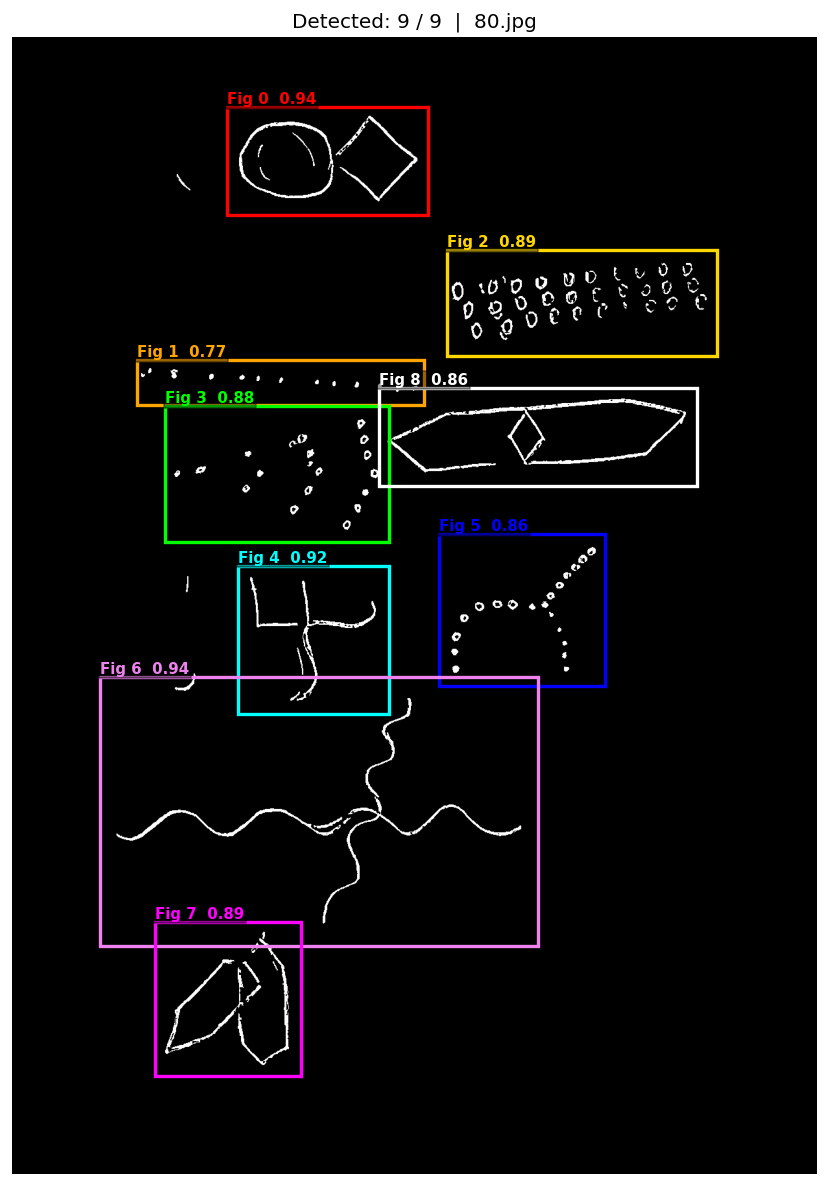

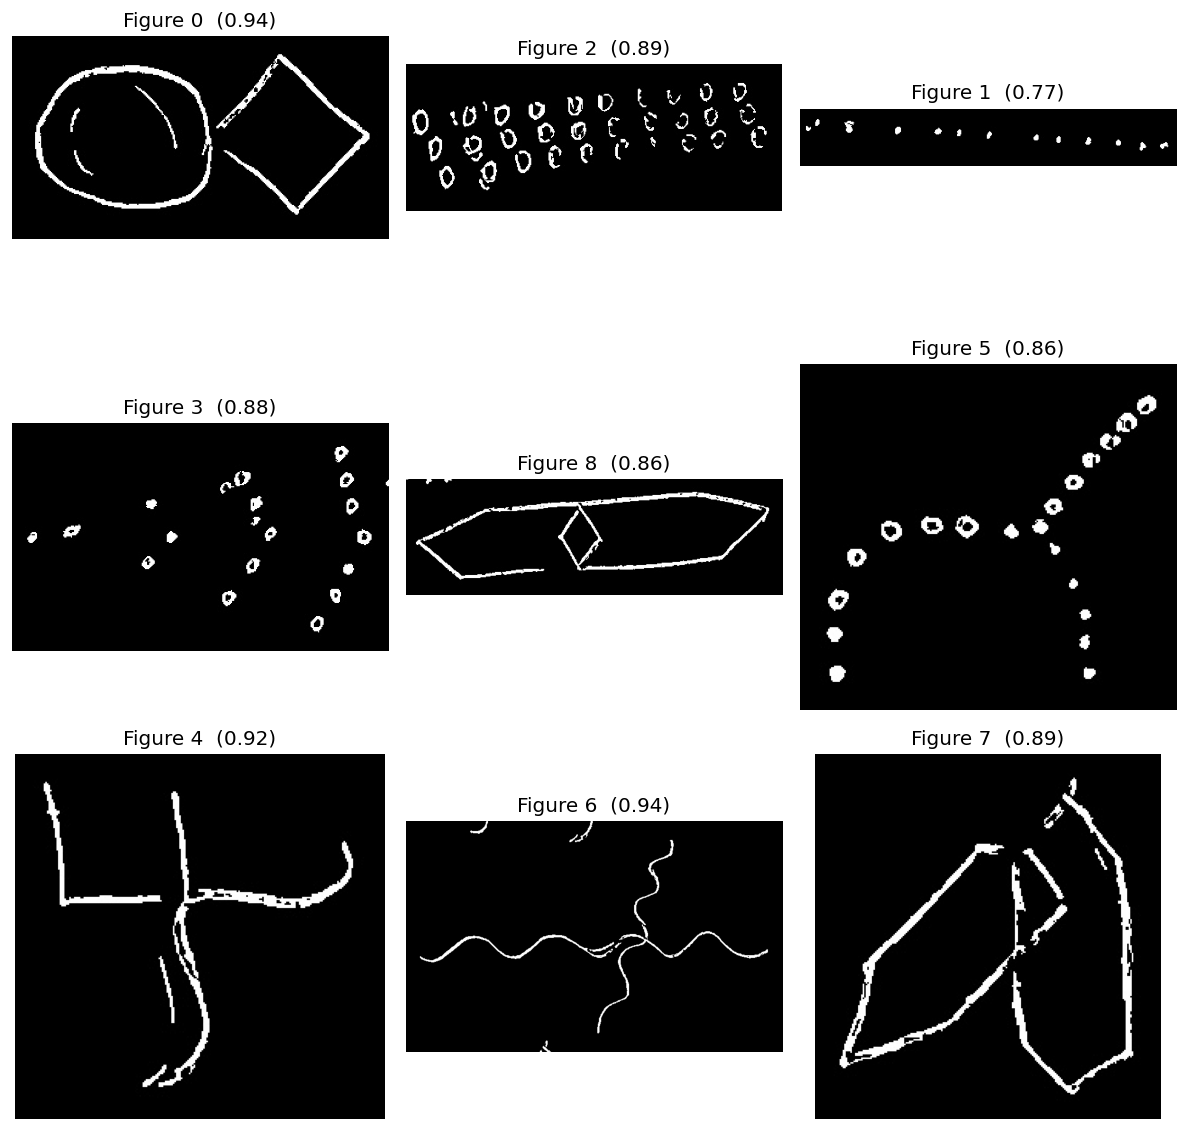

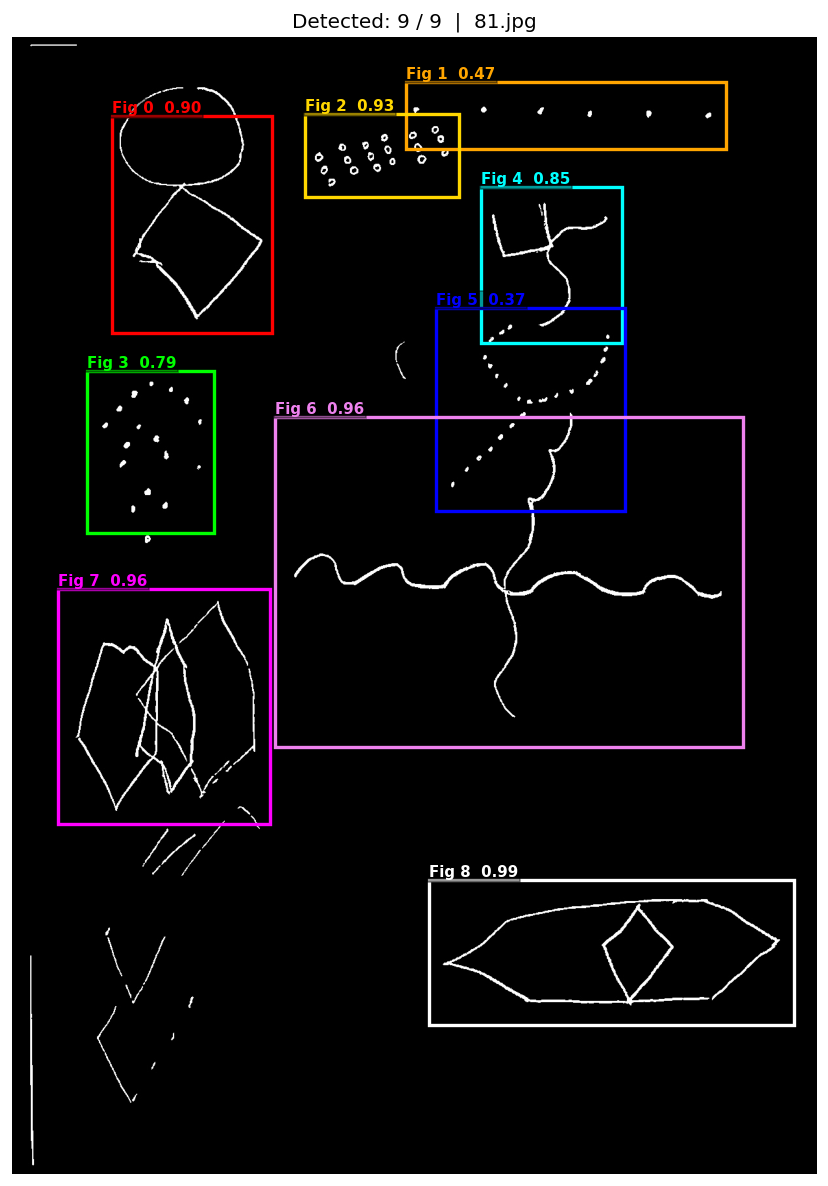

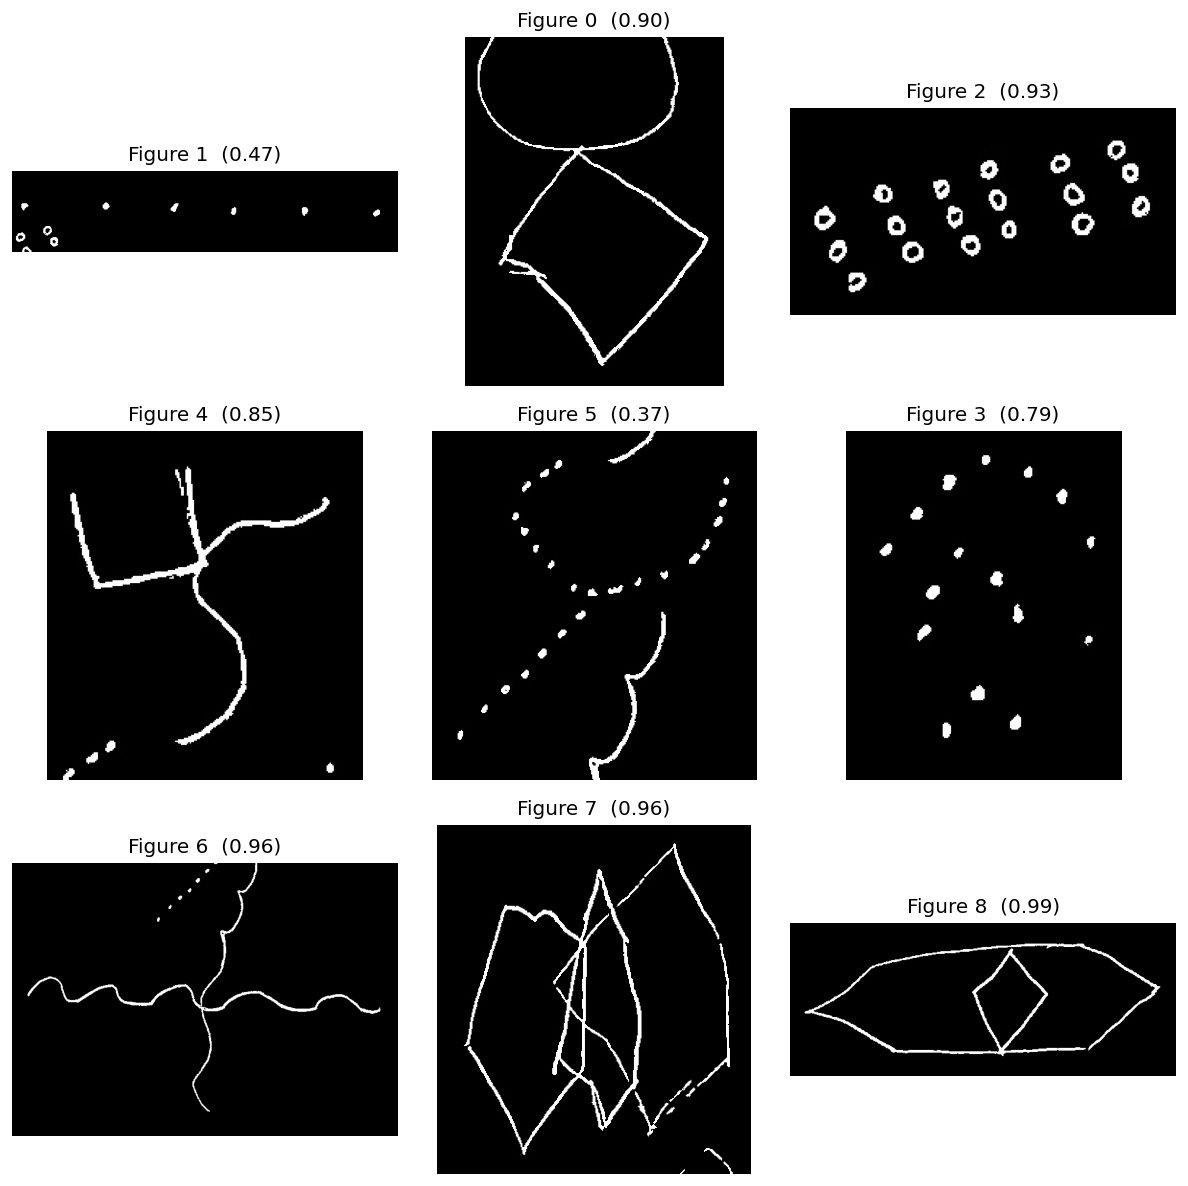

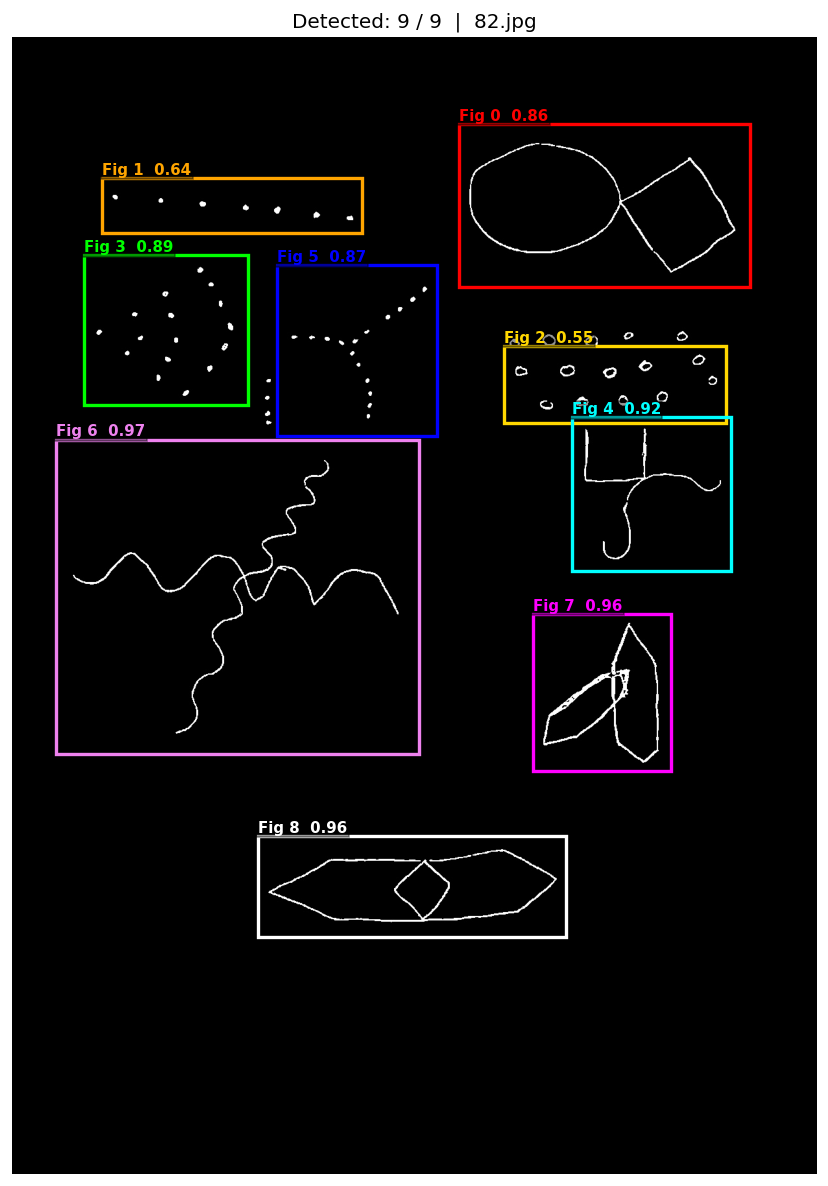

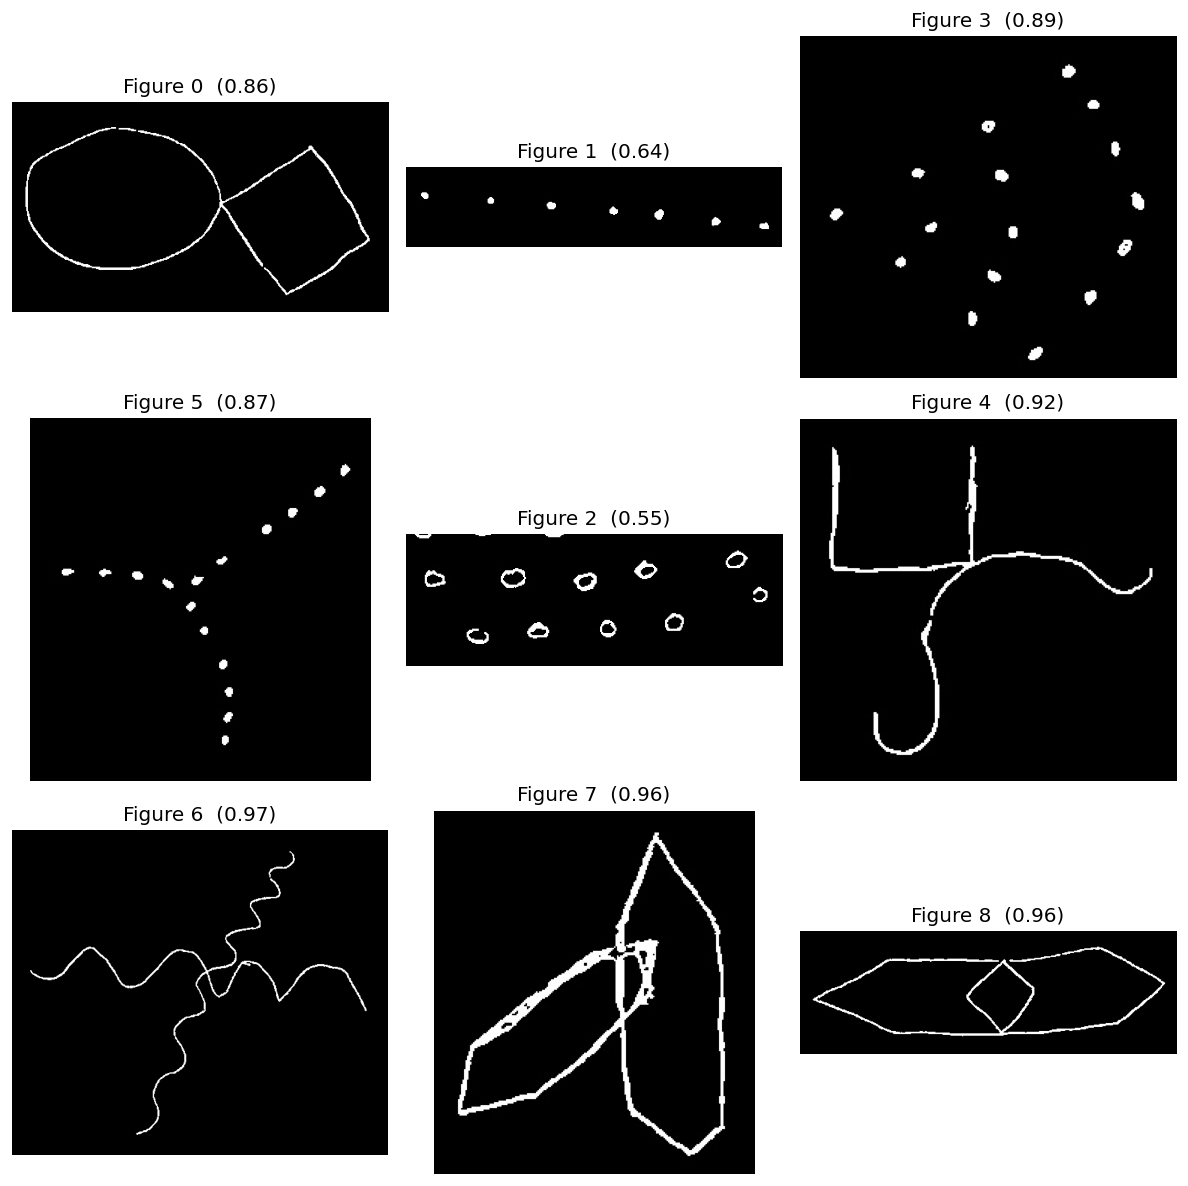

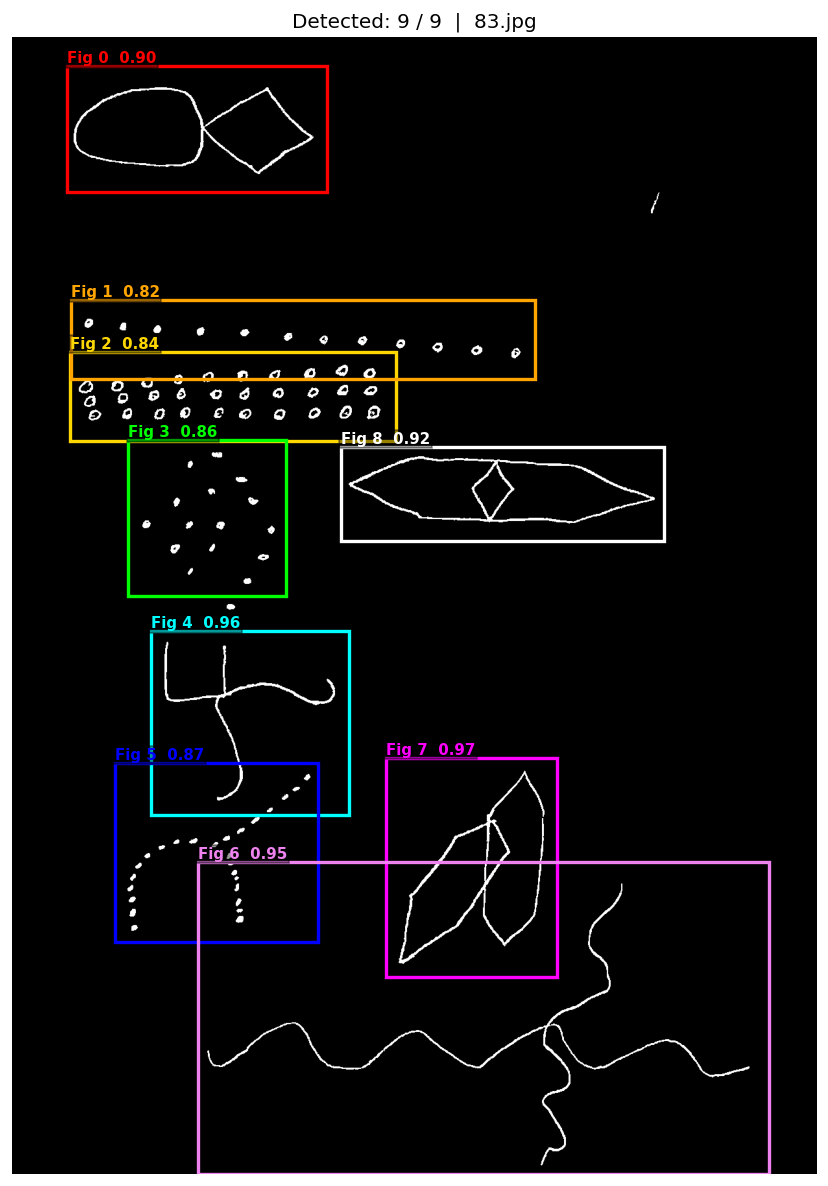

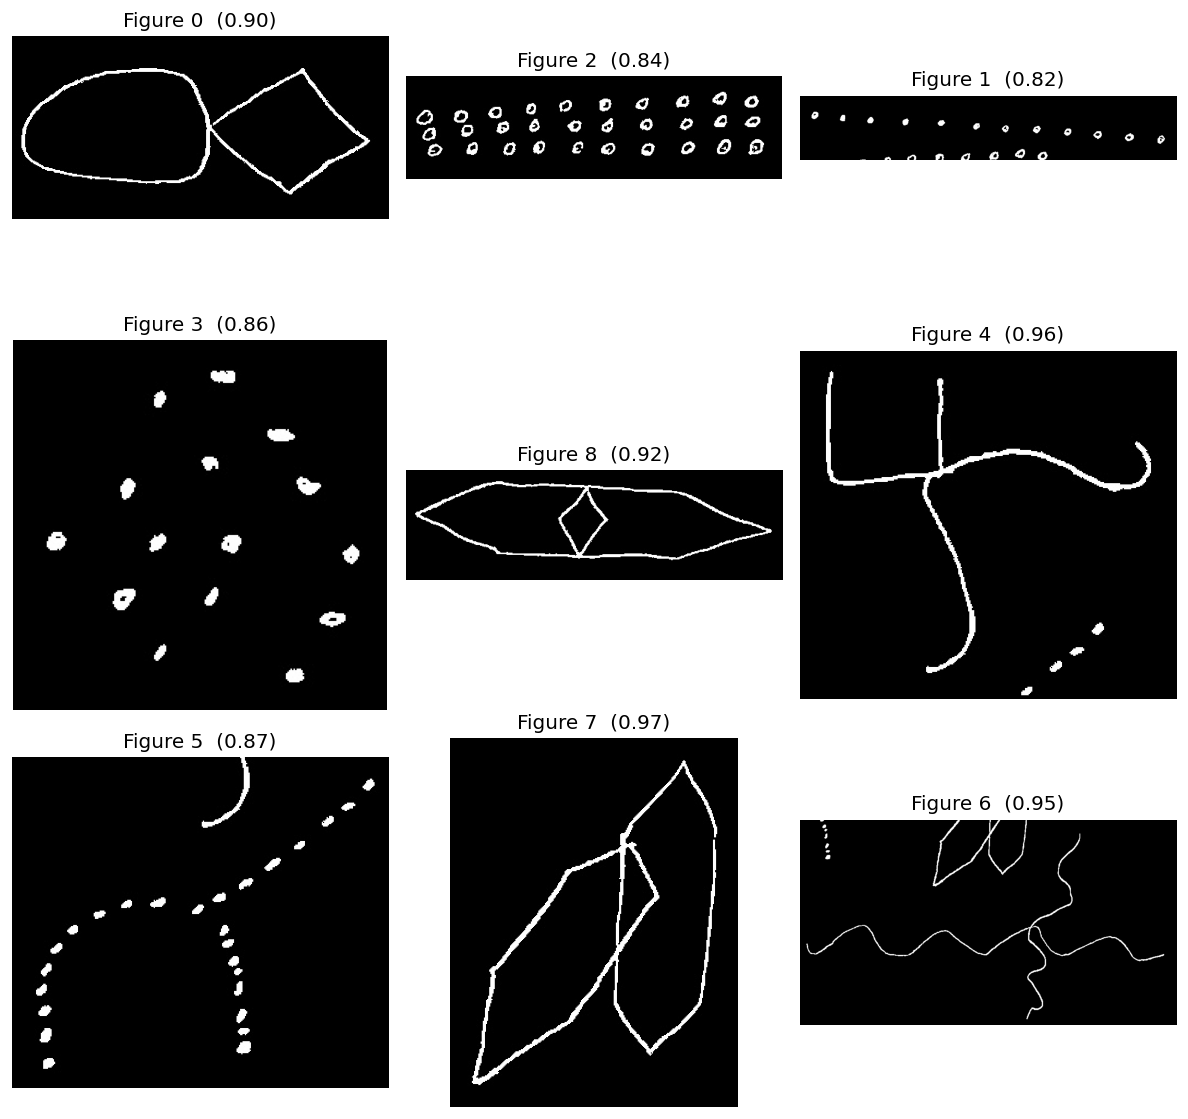

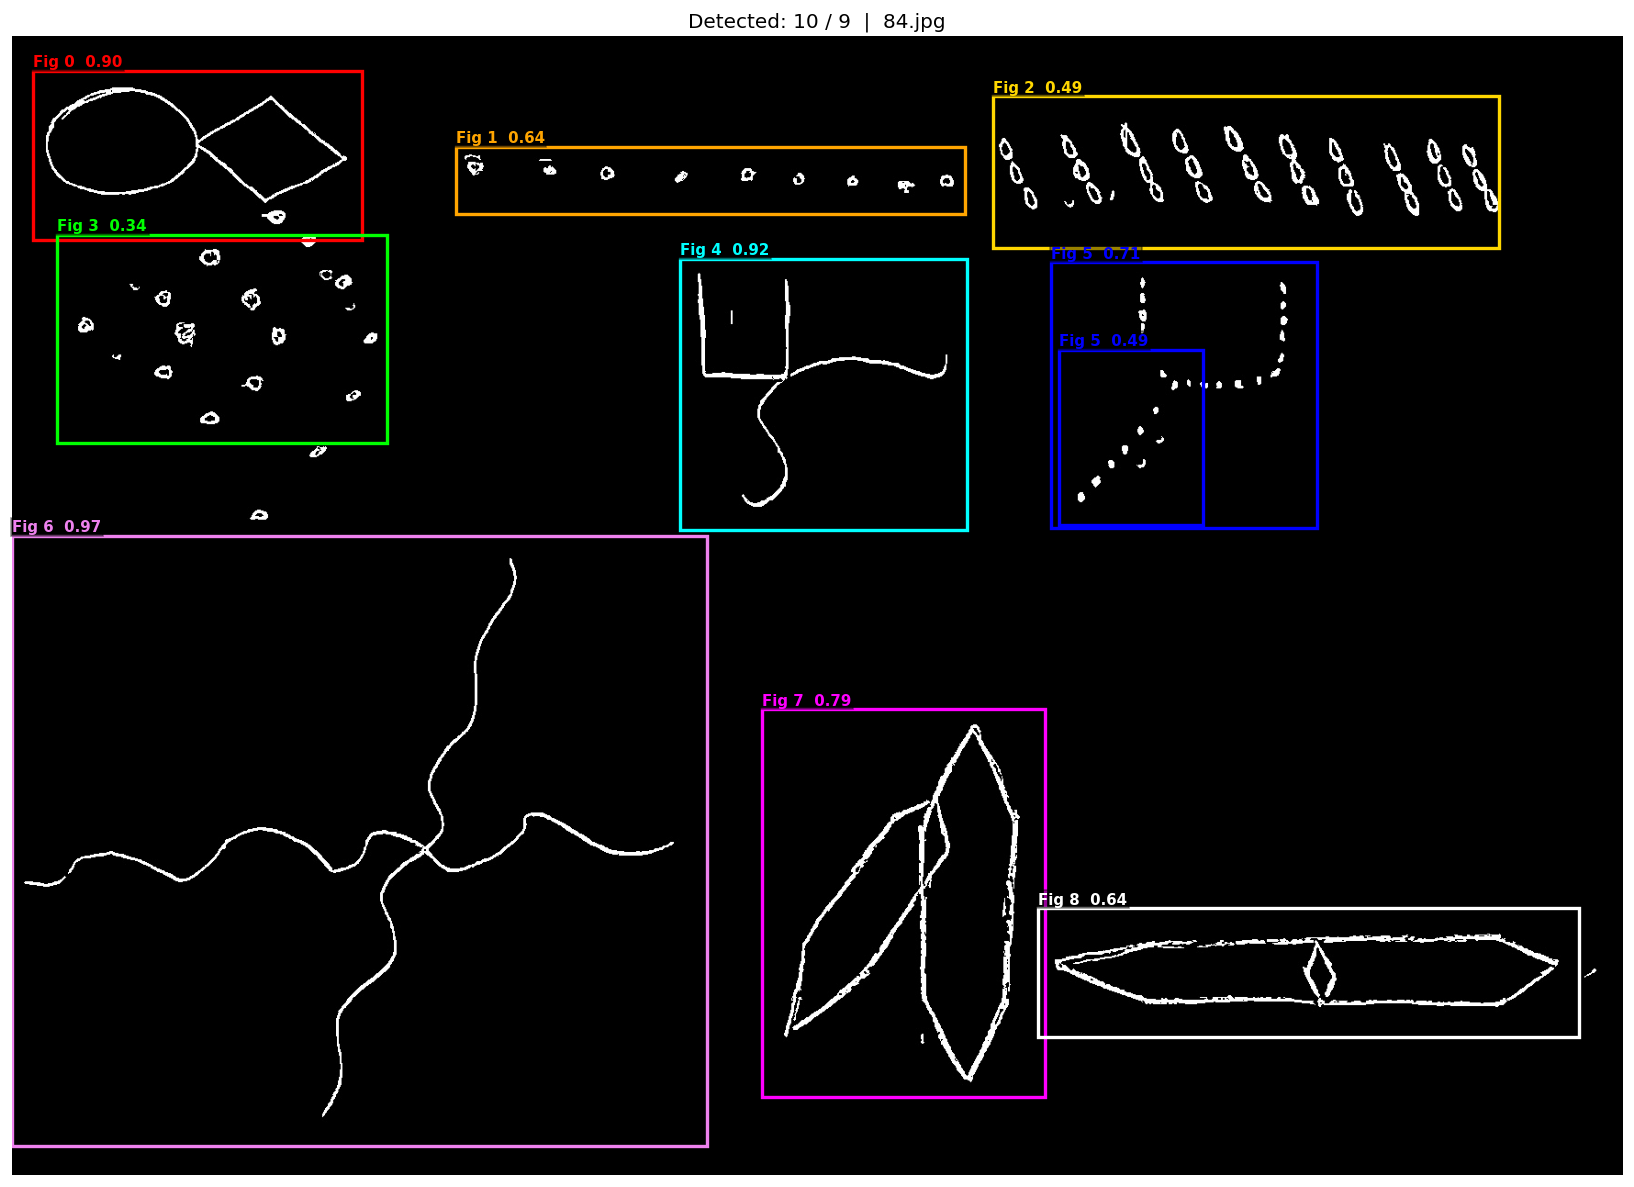

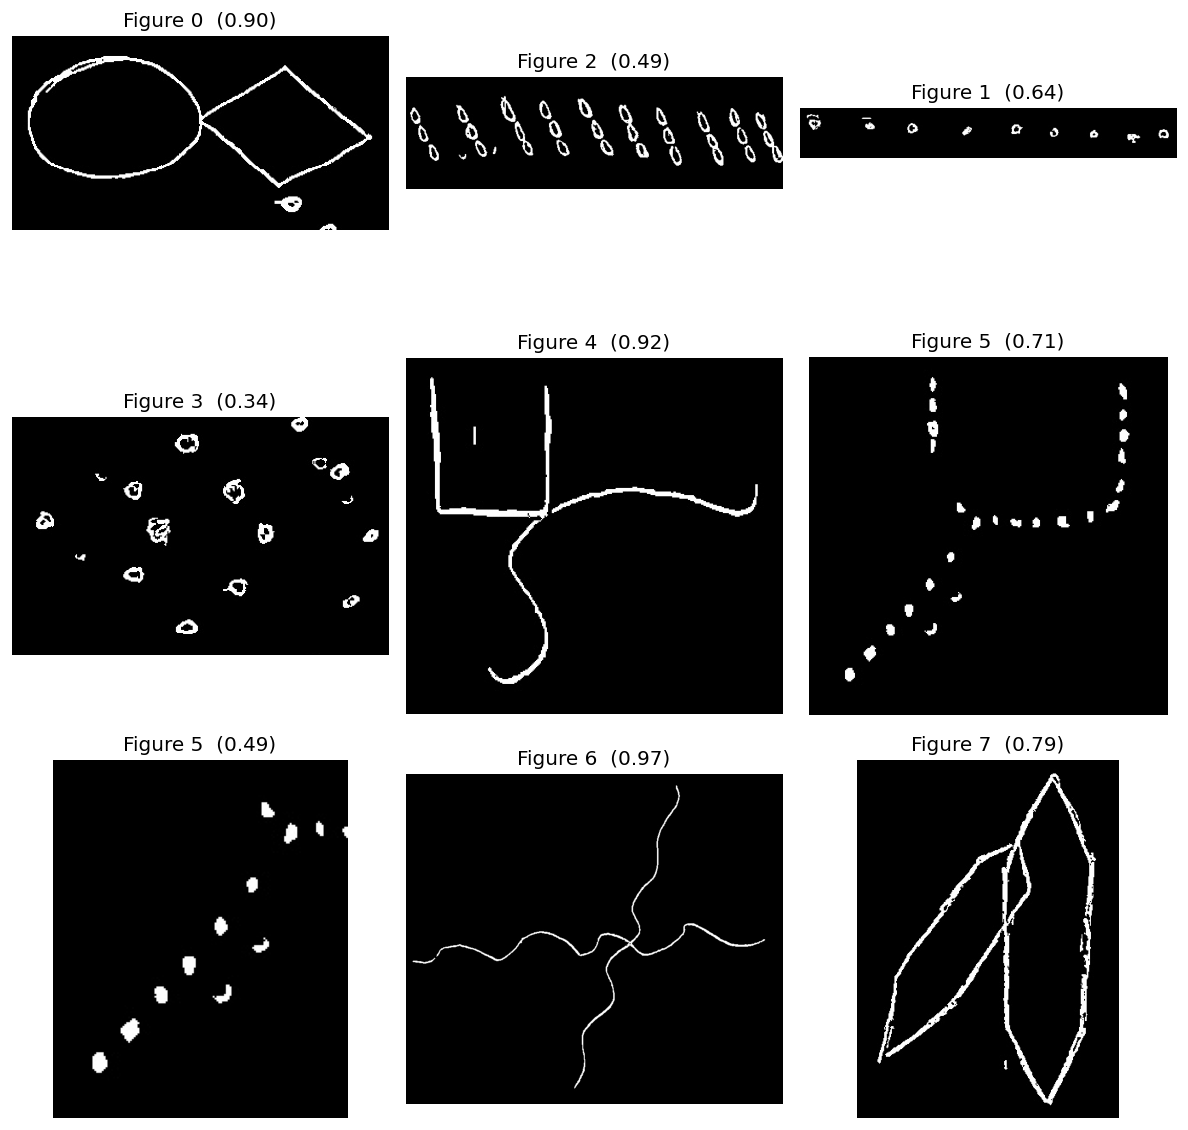

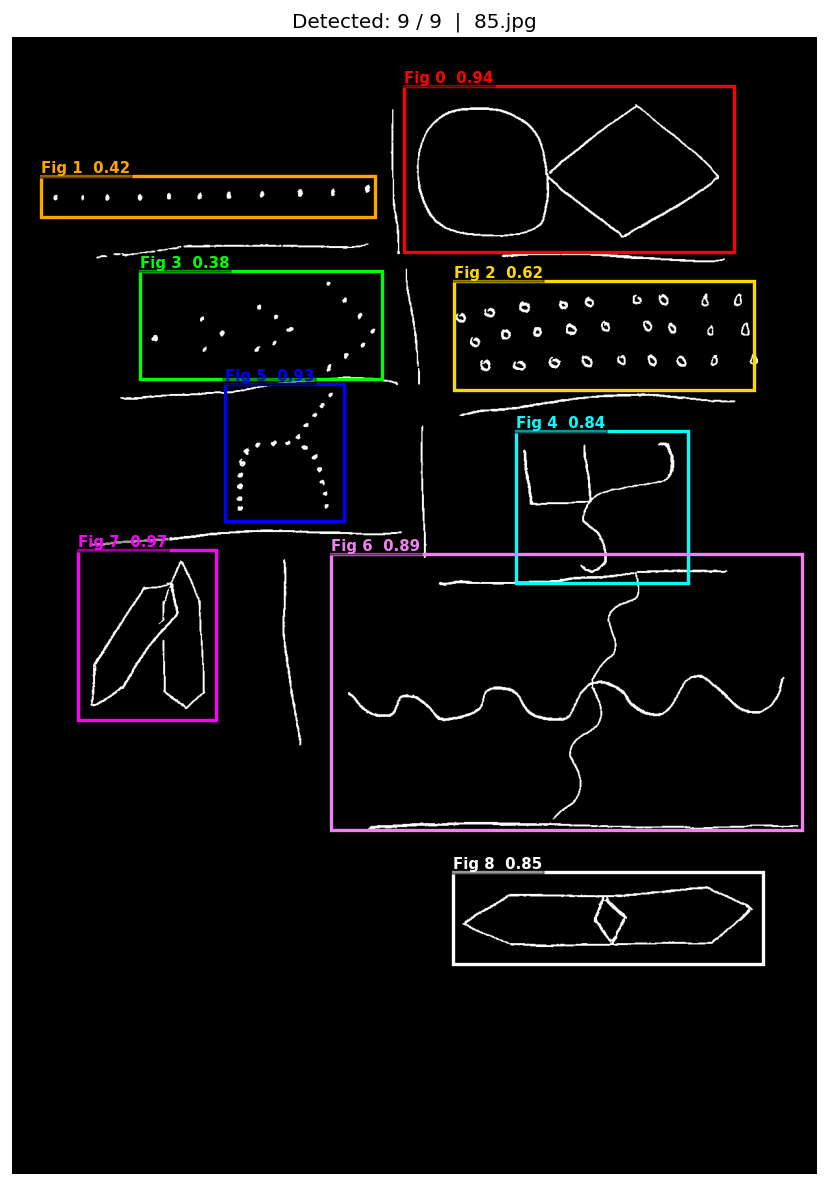

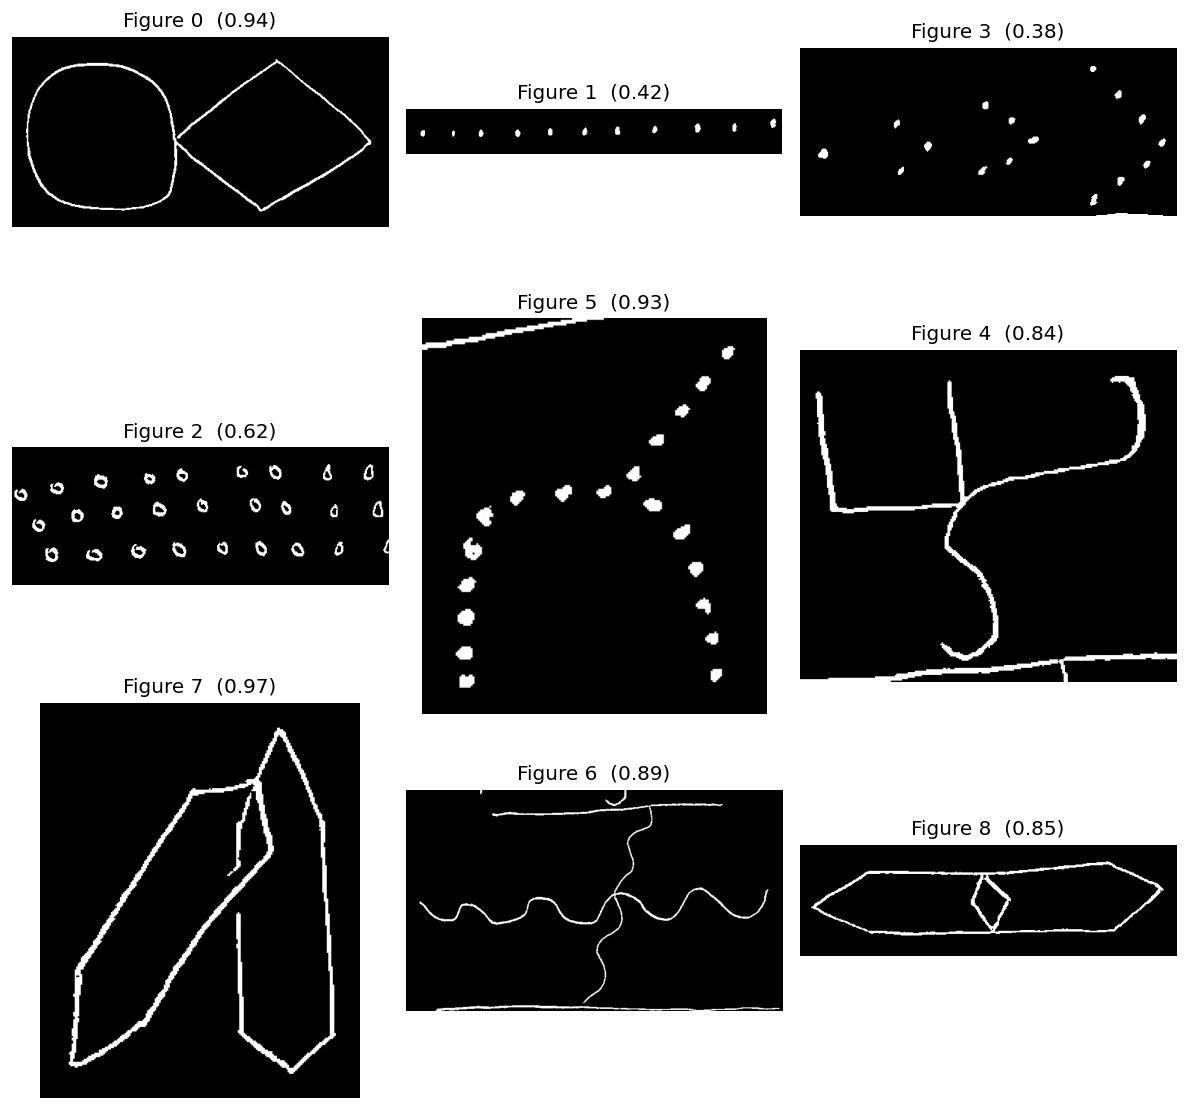

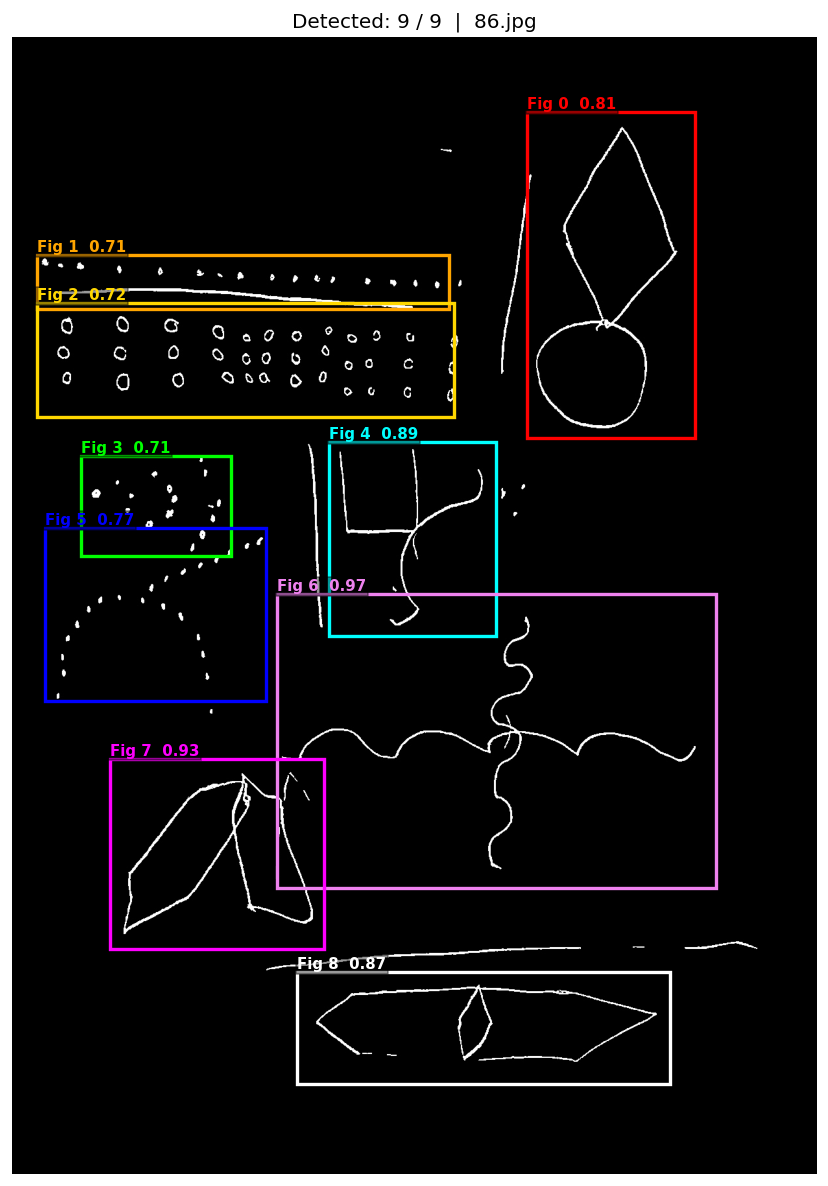

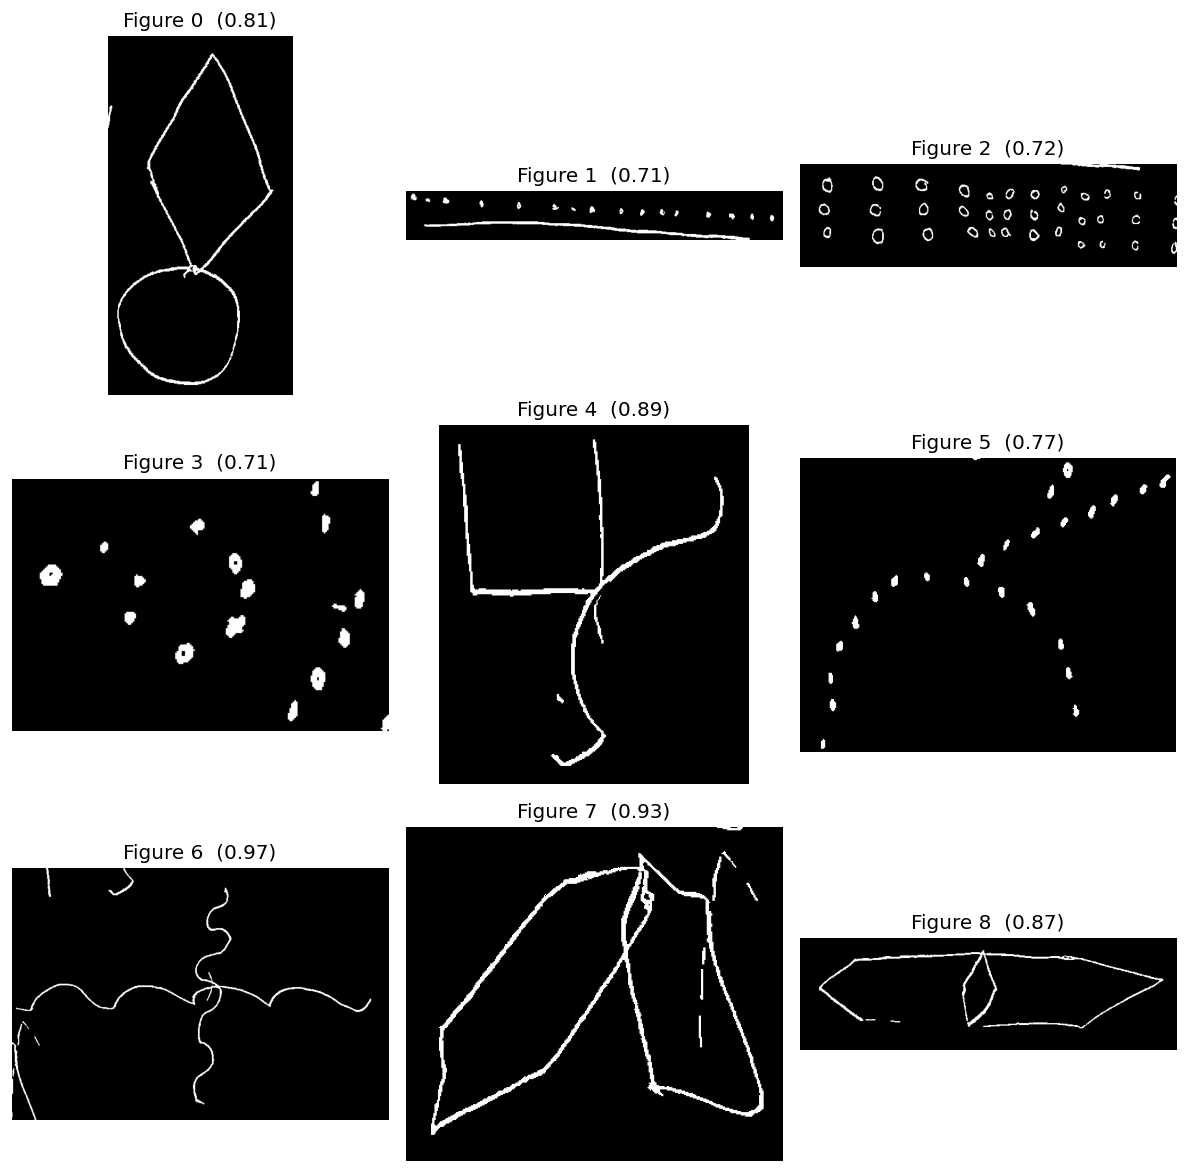

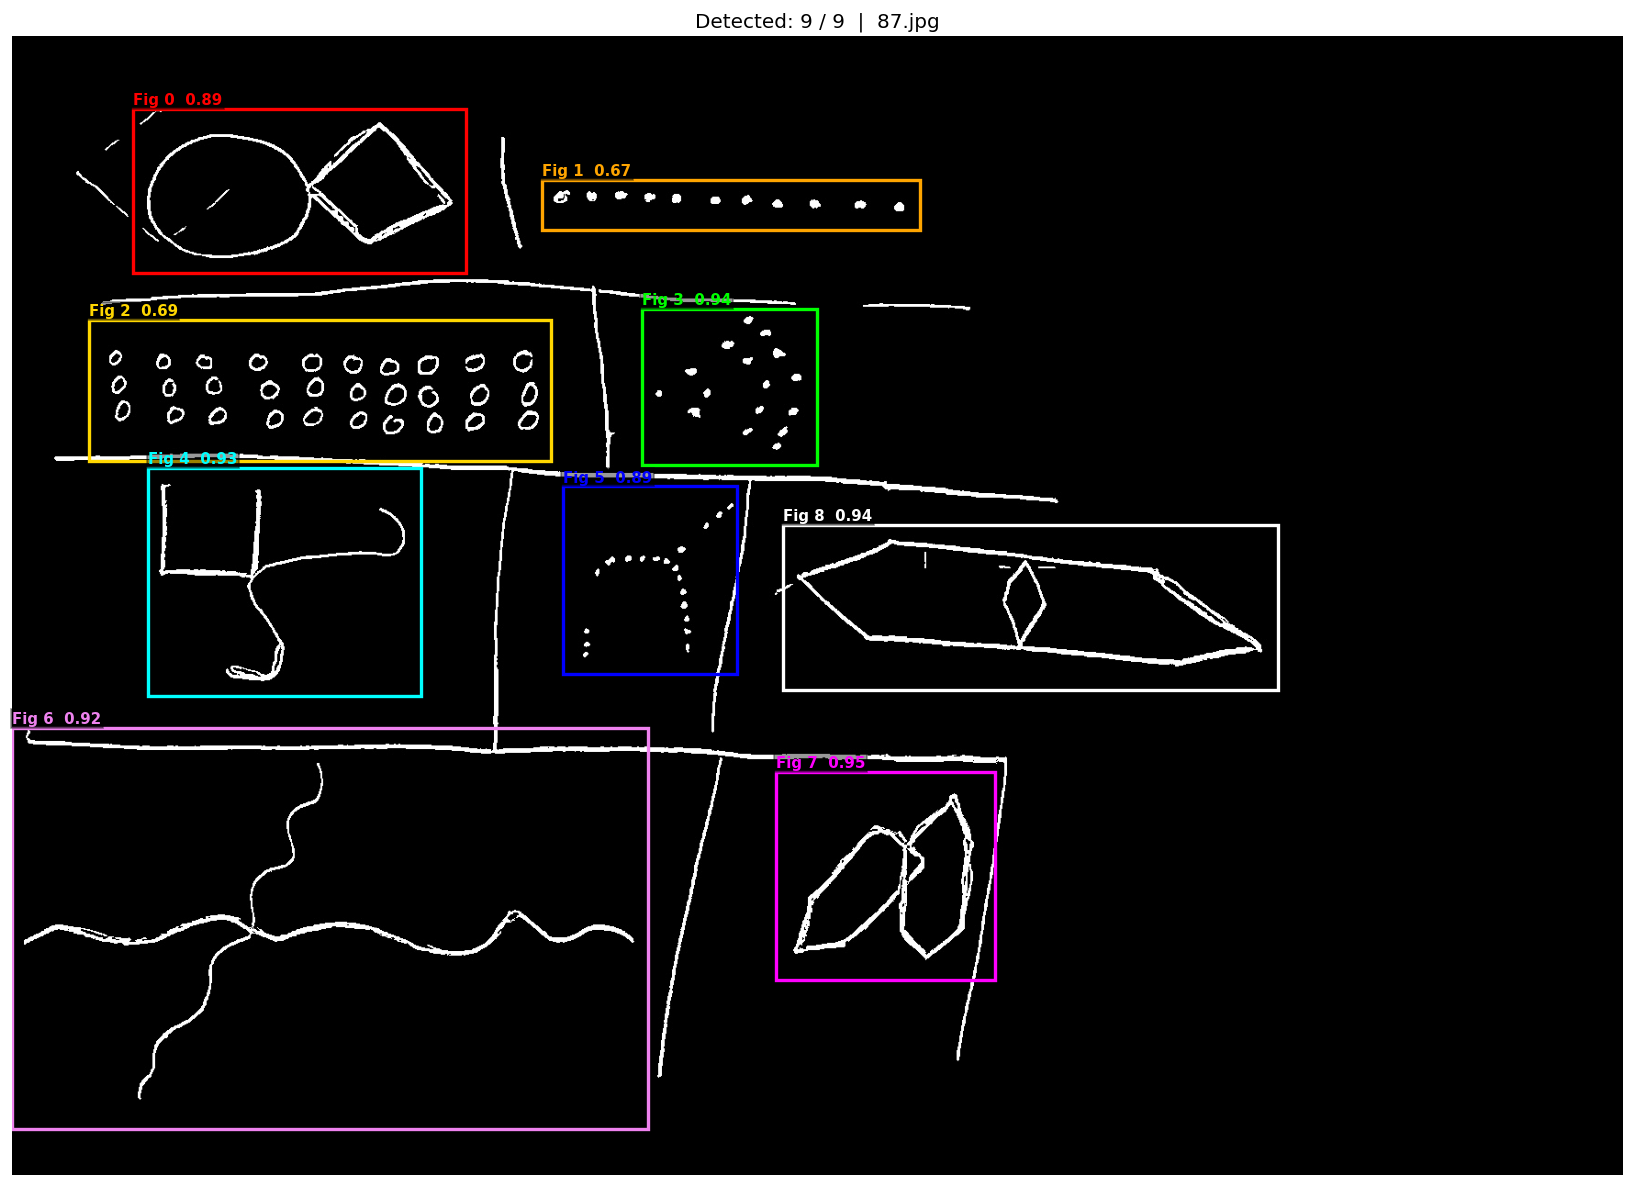

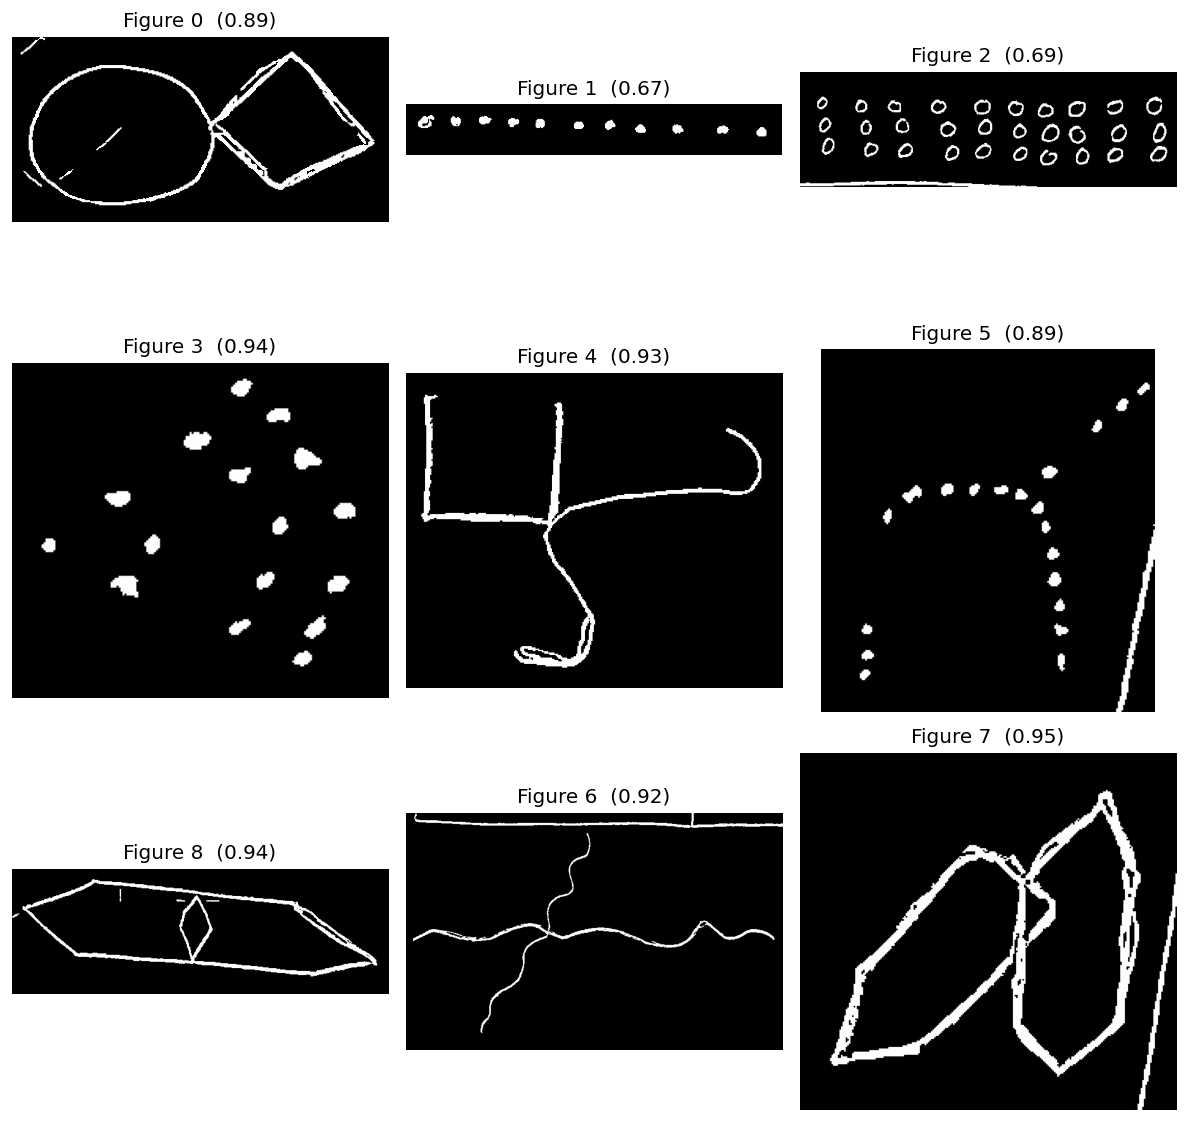

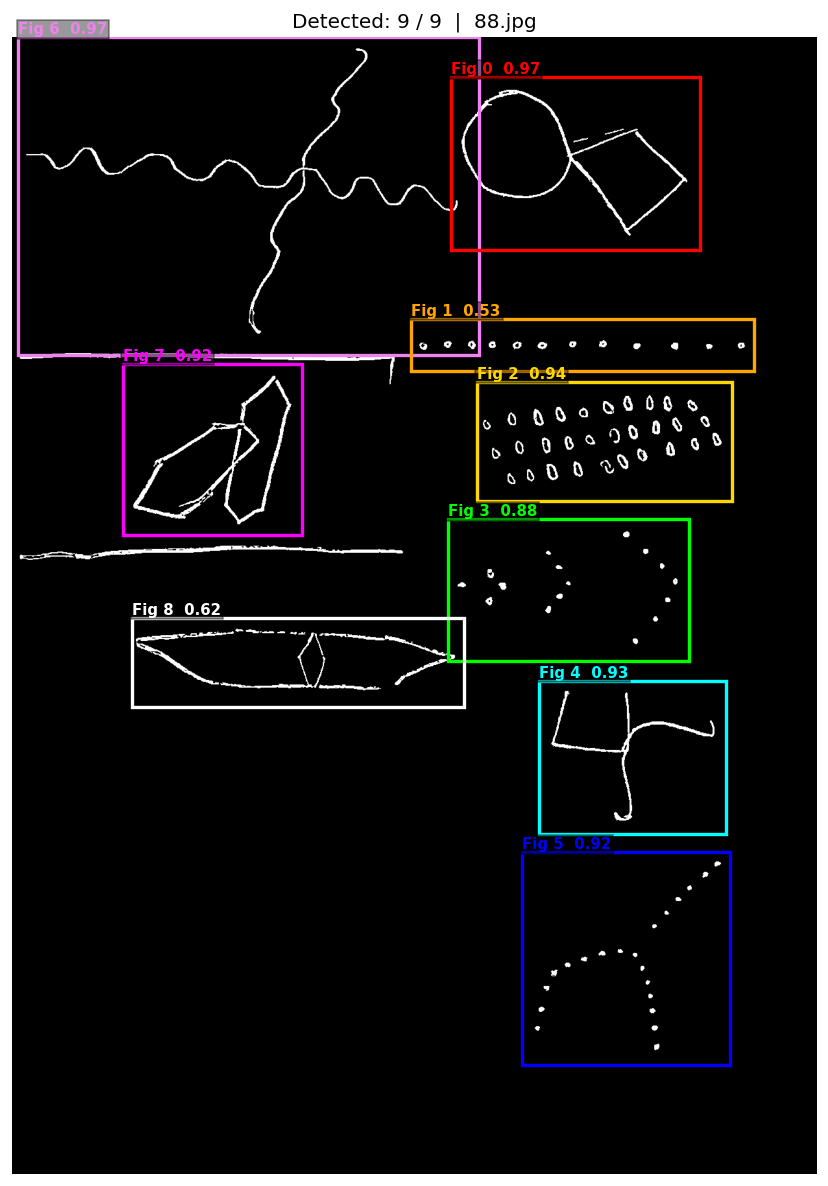

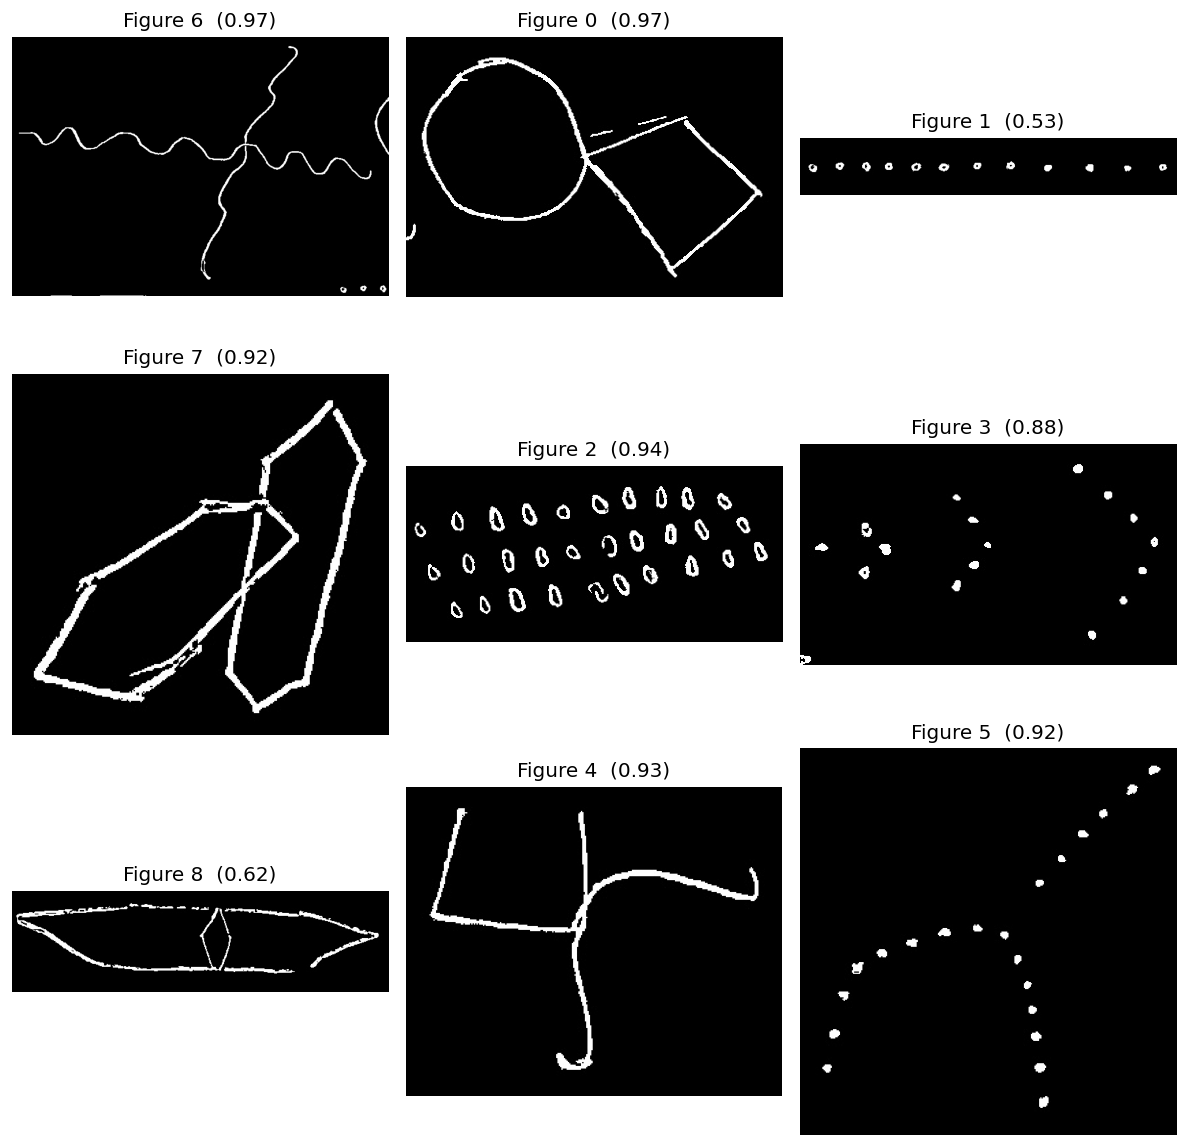

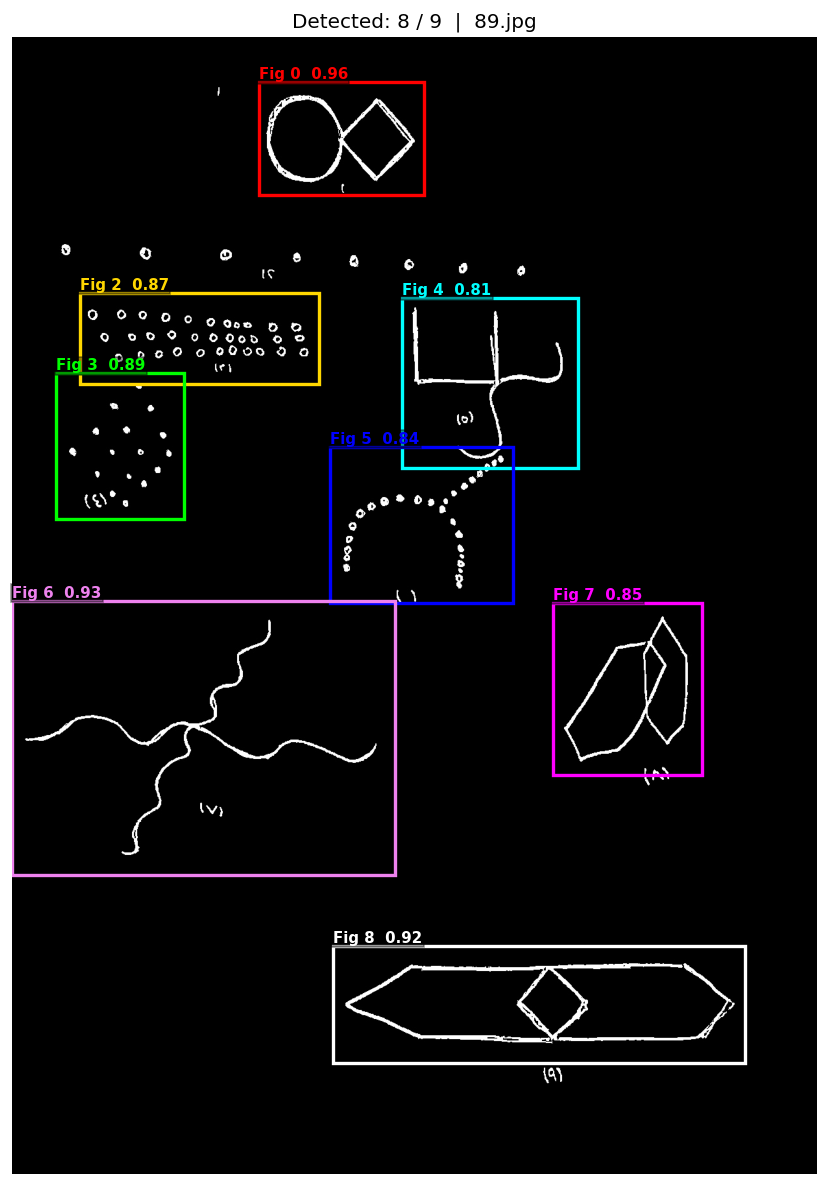

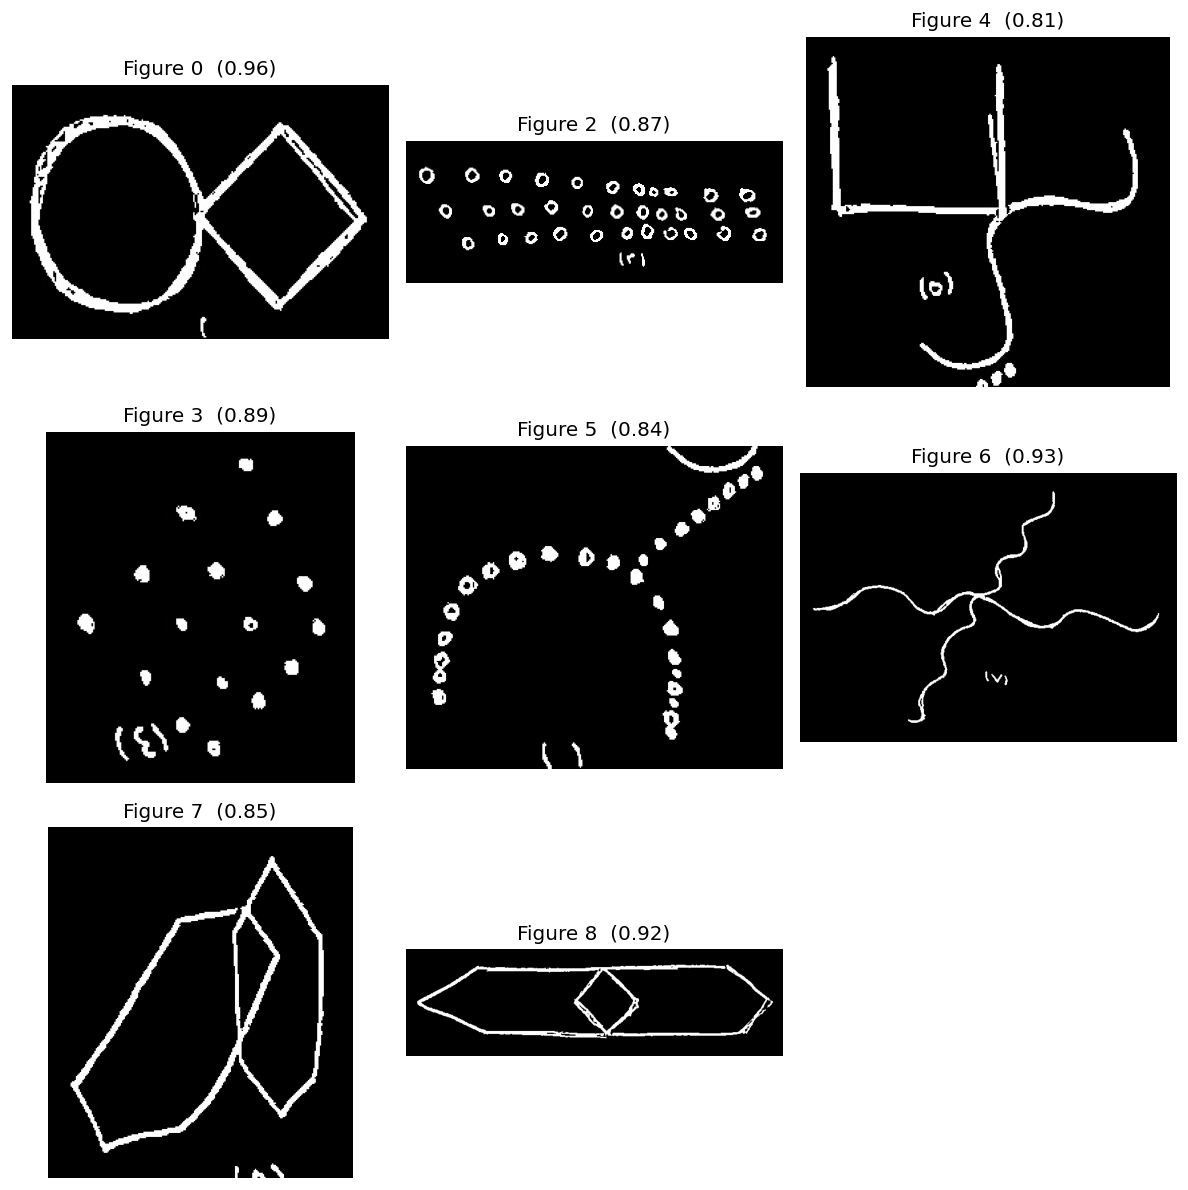


===== Inference Summary =====
 image  detected missing  avg_conf
80.jpg         9       —     0.885
81.jpg         9       —     0.802
82.jpg         9       —     0.848
83.jpg         9       —     0.898
84.jpg        10       —     0.688
85.jpg         9       —     0.760
86.jpg         9       —     0.819
87.jpg         9       —     0.868
88.jpg         9       —     0.854
89.jpg         8       1     0.885


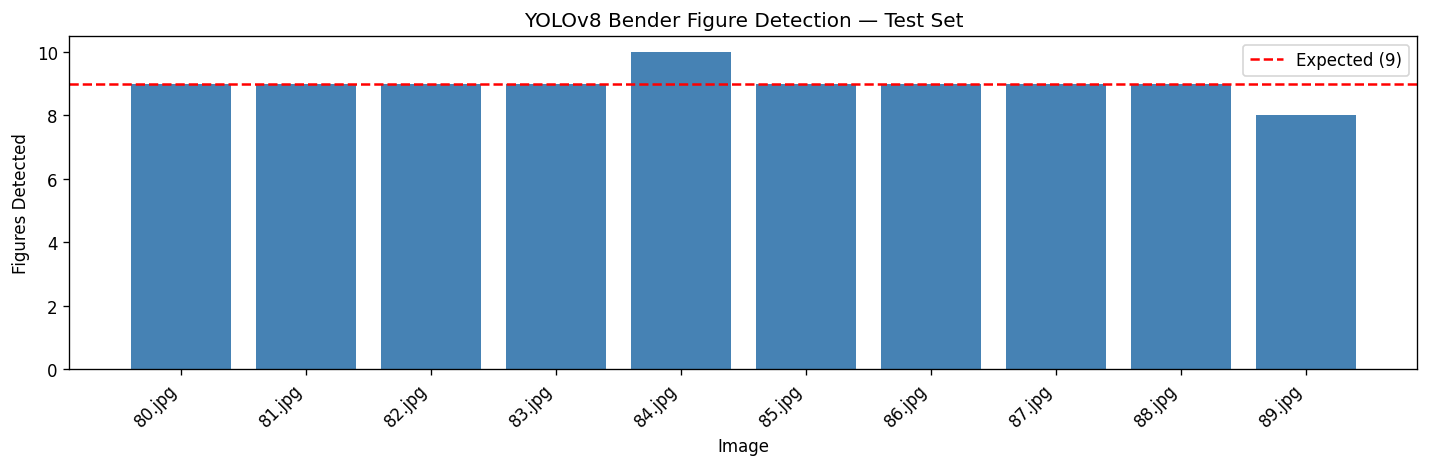

In [19]:
# CELL 7: Run inference on 10 test images + summary report
import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from IPython.display import display, Image as IPImage
from ultralytics import YOLO

TEST_IMAGE_DIR = "/content/Bender_test_Evalution-main/Dataset/test"
MODEL_PATH     = "/content/Bender_test_Evalution-main/runs/detect/bender/train/weights/best.pt"
FIGURE_NAMES   = ["0", "1", "2", "3", "4", "5", "6", "7", "8"]
FIGURE_COLORS  = {
    "0": "red",    "1": "orange", "2": "gold",   "3": "lime",
    "4": "cyan",   "5": "blue",   "6": "violet",  "7": "magenta", "8": "white"
}

def show_inline(fig):
    """Render a matplotlib figure inline in PyCharm notebook output."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    buf.seek(0)
    display(IPImage(data=buf.read()))
    plt.close(fig)

test_images = sorted([
    os.path.join(TEST_IMAGE_DIR, f)
    for f in os.listdir(TEST_IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print(f"Found {len(test_images)} test images\n")

# ── run inference ─────────────────────────────────────────────────────────────
all_results  = {}
summary_rows = []

for img_path in test_images:
    results = extract_bender_figures(img_path, model_path=MODEL_PATH)
    all_results[img_path] = results

    detected_names = results["names"]
    missing        = [n for n in FIGURE_NAMES if n not in detected_names]

    summary_rows.append({
        "image"   : os.path.basename(img_path),
        "detected": len(detected_names),
        "missing" : ", ".join(missing) if missing else "—",
        "avg_conf": round(float(np.mean(results["scores"])), 3) if results["scores"] else 0.0
    })

# ── per-image visualizations ─────────────────────────────────────────────────
for img_path, results in all_results.items():
    img     = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # — annotated full image —
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    ax.imshow(img_rgb)
    for box, name, score in zip(results["boxes"], results["names"], results["scores"]):
        x1, y1, x2, y2 = box
        color = FIGURE_COLORS.get(name, "lime")
        rect  = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f"Fig {name}  {score:.2f}",
                color=color, fontsize=9, fontweight="bold",
                bbox=dict(facecolor="black", alpha=0.4, pad=1))
    ax.set_title(f"Detected: {len(results['boxes'])} / 9  |  {os.path.basename(img_path)}")
    ax.axis("off")
    plt.tight_layout()
    show_inline(fig)

    # — 3×3 crop grid —
    crops = results["crops"]
    if crops:
        fig2, axes = plt.subplots(3, 3, figsize=(10, 10))
        for idx, ax2 in enumerate(axes.flat):
            if idx < len(crops):
                ax2.imshow(crops[idx], cmap="gray")
                ax2.set_title(f"Figure {results['names'][idx]}  ({results['scores'][idx]:.2f})")
            ax2.axis("off")
        plt.tight_layout()
        show_inline(fig2)

# ── summary table ─────────────────────────────────────────────────────────────
summary_df = pd.DataFrame(summary_rows)
print("\n===== Inference Summary =====")
print(summary_df.to_string(index=False))

# ── bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
x_pos = range(len(summary_df))
ax.bar(x_pos, summary_df["detected"], color="steelblue")
ax.axhline(9, color="red", linestyle="--", label="Expected (9)")
ax.set_xlabel("Image")
ax.set_ylabel("Figures Detected")
ax.set_title("YOLOv8 Bender Figure Detection — Test Set")
ax.set_xticks(x_pos)
ax.set_xticklabels(summary_df["image"], rotation=45, ha="right")
ax.legend()
plt.tight_layout()
show_inline(fig)

---
## Gestalt Feature Extraction
> Uses the bounding boxes from the YOLO txt files to crop each figure,
> then compares the student crop to the original template from `template_features.pkl`.
> Each of the 8 Gestalt features has its own algorithm cell — fill them in one by one.

### Setup — Load Templates & Define Helpers

In [74]:
import cv2
import numpy as np
import pickle
import csv
from skimage import measure
from collections import defaultdict

#  Paths
PREPROCESSED_DIR = "/content/Bender_test_Evalution-main/Dataset/Preprocessed"
TXT_DIR          = "/content/Bender_test_Evalution-main/Dataset/train"
TEMPLATE_PKL     = "/content/Bender_test_Evalution-main/Dataset/templates_Preprocessed/template_features.pkl"
LABELS_CSV       = "/content/Bender_test_Evalution-main/Dataset/Bender_test.csv"
OUTPUT_CSV       = "gestalt_results.csv"

#  Load templates
with open(TEMPLATE_PKL, "rb") as f:
    PKL = pickle.load(f)

TEMPLATES  = PKL["templates"]
TMPL_FEATS = PKL["features"]

# class mapping
TXT_TO_PKL = {i: str(i + 1) for i in range(9)}
FIG_NAMES  = {0:"A", 1:"1", 2:"2", 3:"3", 4:"4", 5:"5", 6:"6", 7:"7", 8:"8"}

# Crop student shapes
def crop_student_shapes(image_path, txt_path):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")

    h, w = img.shape
    shapes = defaultdict(list)

    with open(txt_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            cls = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:])

            x1 = max(0, int((cx - bw/2) * w))
            y1 = max(0, int((cy - bh/2) * h))
            x2 = min(w, int((cx + bw/2) * w))
            y2 = min(h, int((cy + bh/2) * h))

            crop = img[y1:y2, x1:x2]

            shapes[cls].append(crop)

    return shapes


# Template crop
def get_template_crop(class_id):

    key = TXT_TO_PKL[class_id]
    tmpl_img = TEMPLATES[key]["image"]
    x, y, tw, th = TMPL_FEATS[key]["bounding_box"]

    pad = 20
    crop = tmpl_img[max(0, y-pad):y+th+pad, max(0, x-pad):x+tw+pad]

    _, binary = cv2.threshold(crop, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    return binary.astype(np.uint8)


# Binary helper (IMPORTANT FIXED VERSION)
def to_binary(img):

    if isinstance(img, list):
        if len(img) == 0:
            return None
        img = img[0]

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, binary = cv2.threshold(
        img,
        0,
        1,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    return binary.astype(np.uint8)


print("Gestalt setup ready")
print("Templates loaded:", list(TEMPLATES.keys()))

Gestalt setup ready
Templates loaded: ['1', '2', '3', '4', '5', '6', '7', '8', '9']


### Algorithm 1 — Gestalt Fragmentation
**Definition:** Shape is broken into separate disconnected pieces.
**How:** Count connected components in student crop vs template. If student has significantly more → Fragmentation = True.

In [80]:
from skimage import measure
import numpy as np

def detect_fragmentation(student_bin, template_bin):

    def count_components(binary):
        labeled = measure.label(binary, connectivity=2)
        regions = measure.regionprops(labeled)
        return len([r for r in regions if r.area > 30])

    s_count = count_components(student_bin)
    t_count = count_components(template_bin)

    # Allow proportional tolerance: student can have up to 50% more + 1
    threshold = max(t_count * 1.5 + 1, t_count + 2)
    detected = s_count > threshold

    detail = (f"student={s_count}, template={t_count}, "
              f"threshold={threshold:.1f}, detected={detected}")
    return detected, detail



### Algorithm 2 — Closure Difficulties
**Definition:** Shape has gaps / openings where lines don't close.
**How:** [ TO BE FILLED after visual analysis ]

In [81]:
import cv2
import numpy as np
from skimage import measure

def detect_closure(student_bin, template_bin):
    import cv2, numpy as np
    from skimage import measure

    def contour_closure_score(binary):
        """Returns 0=closed, 1=very open"""
        b = (binary * 255).astype(np.uint8)
        # Dilate slightly to connect near-closed gaps
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
        b_closed = cv2.morphologyEx(b, cv2.MORPH_CLOSE, kernel, iterations=2)

        contours_raw, _ = cv2.findContours(b, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        contours_cls, _ = cv2.findContours(b_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

        if not contours_raw or not contours_cls:
            return 0.0

        # Compare area before and after closing
        area_raw = sum(cv2.contourArea(c) for c in contours_raw)
        area_cls = sum(cv2.contourArea(c) for c in contours_cls)

        if area_cls < 1:
            return 0.0

        # The more area was "filled in" by closing, the more gaps existed
        gap_ratio = (area_cls - area_raw) / (area_cls + 1e-6)
        return float(np.clip(gap_ratio, 0, 1))

    s_score = contour_closure_score(student_bin)
    t_score = contour_closure_score(template_bin)

    # Student has MORE gaps than template
    gap_diff = s_score - t_score
    detected = gap_diff > 0.08

    detail = (f"student_gap={s_score:.3f}, template_gap={t_score:.3f}, "
              f"diff={gap_diff:.3f}")
    return detected, detail


### Algorithm 3 — Drawing Axis Rotation
**Definition:** Shape is rotated compared to the original.
**How:** [ TO BE FILLED after visual analysis ]

In [82]:
import cv2
import numpy as np
from skimage import measure

def detect_rotation(student_bin, template_bin):
    def get_pca_angle(binary):
        ys, xs = np.where(binary > 0)
        if len(xs) < 20:
            return None
        pts = np.column_stack([xs, ys]).astype(float)
        pts -= pts.mean(axis=0)
        cov = np.cov(pts.T)
        if cov.ndim < 2:
            return 0.0
        eigvals, eigvecs = np.linalg.eigh(cov)
        main_vec = eigvecs[:, np.argmax(eigvals)]
        angle = np.degrees(np.arctan2(main_vec[1], main_vec[0]))
        return angle

    def eccentricity(binary):
        labeled = measure.label(binary, connectivity=2)
        regions = [r for r in measure.regionprops(labeled) if r.area > 100]
        if not regions:
            return 1.0
        r = max(regions, key=lambda x: x.area)
        return r.eccentricity

    s_angle = get_pca_angle(student_bin)
    t_angle = get_pca_angle(template_bin)

    if s_angle is None or t_angle is None:
        return False, "insufficient pixels"

    # If template is nearly round (low eccentricity), rotation is not meaningful
    t_ecc = eccentricity(template_bin)
    if t_ecc < 0.3:
        return False, f"template nearly circular (ecc={t_ecc:.2f}), rotation N/A"

    diff = abs(s_angle - t_angle)
    diff = min(diff, 180 - diff) if diff > 90 else diff

    detected = diff > 25
    return detected, f"s_angle={s_angle:.1f}°, t_angle={t_angle:.1f}°, diff={diff:.1f}°"

print("Algorithm 3 (Rotation): READY")


Algorithm 3 (Rotation): READY


### Algorithm 4 — Changes in Curvatures
**Definition:** Curvature of shape differs from original.
**How:** [ TO BE FILLED after visual analysis ]

In [83]:
import cv2
import numpy as np
from skimage import measure
from skimage.morphology import skeletonize

def detect_curvature_changes(student_bin, template_bin):
    def curvature_density(binary):
        b = (binary * 255).astype(np.uint8)
        # Skeletonize
        skel = skeletonize(binary > 0).astype(np.uint8)
        skel_pts = np.column_stack(np.where(skel > 0))
        skel_len = len(skel_pts)
        if skel_len < 10:
            return 0.0

        # Find contour of original shape for curvature
        contours, _ = cv2.findContours(b, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        if not contours:
            return 0.0
        cnt = max(contours, key=cv2.contourArea)
        if len(cnt) < 10:
            return 0.0

        pts = cnt.reshape(-1, 2).astype(float)
        n = len(pts)
        step = max(1, n // 100)  # sample at most 100 points

        angles = []
        for i in range(0, n, step):
            p0 = pts[(i - step) % n]
            p1 = pts[i]
            p2 = pts[(i + step) % n]
            v1 = p1 - p0
            v2 = p2 - p1
            norm1 = np.linalg.norm(v1)
            norm2 = np.linalg.norm(v2)
            if norm1 < 1e-6 or norm2 < 1e-6:
                continue
            cos_a = np.clip(np.dot(v1, v2) / (norm1 * norm2), -1, 1)
            angles.append(np.degrees(np.arccos(cos_a)))

        if not angles:
            return 0.0

        # Mean turning angle normalized
        return float(np.mean(angles))

    s_curv = curvature_density(student_bin)
    t_curv = curvature_density(template_bin)

    if t_curv < 1e-6:
        return False, "template has no curvature reference"

    # Ratio: how different is student curvature from template
    ratio = abs(s_curv - t_curv) / (t_curv + 1e-6)
    detected = ratio > 0.35

    detail = f"s_curv={s_curv:.2f}°, t_curv={t_curv:.2f}°, ratio={ratio:.2f}"
    return detected, detail

print("Algorithm 4 (Curvatures): READY")


Algorithm 4 (Curvatures): READY


### Algorithm 5 — Changes in Angle Size
**Definition:** Angles in the shape are distorted vs original.
**How:** [ TO BE FILLED after visual analysis ]

In [84]:
import cv2
import numpy as np
from skimage import measure

def detect_angle_changes(student_bin, template_bin):
    def get_corner_angles(binary):
        b = (binary * 255).astype(np.uint8)
        contours, _ = cv2.findContours(b, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return [], 1.0

        cnt = max(contours, key=cv2.contourArea)
        perimeter = cv2.arcLength(cnt, True)
        if perimeter < 10:
            return [], 1.0

        # Approximate polygon
        epsilon = 0.04 * perimeter
        approx = cv2.approxPolyDP(cnt, epsilon, True)

        pts = approx.reshape(-1, 2).astype(float)
        n = len(pts)
        if n < 3:
            return [], 1.0

        angles = []
        for i in range(n):
            p0 = pts[(i - 1) % n]
            p1 = pts[i]
            p2 = pts[(i + 1) % n]
            v1 = p0 - p1
            v2 = p2 - p1
            norm1 = np.linalg.norm(v1)
            norm2 = np.linalg.norm(v2)
            if norm1 < 1e-6 or norm2 < 1e-6:
                continue
            cos_a = np.clip(np.dot(v1, v2) / (norm1 * norm2), -1, 1)
            angles.append(np.degrees(np.arccos(cos_a)))

        x, y, w, h = cv2.boundingRect(cnt)
        ar = w / (h + 1e-6)
        return angles, ar

    s_angles, s_ar = get_corner_angles(student_bin)
    t_angles, t_ar = get_corner_angles(template_bin)

    # If no corners detected on either, check aspect ratio only
    if not s_angles or not t_angles:
        ar_diff = abs(s_ar - t_ar) / (t_ar + 1e-6)
        detected = ar_diff > 0.35
        return detected, f"no corners, ar_diff={ar_diff:.2f}"

    s_mean_angle = np.mean(s_angles)
    t_mean_angle = np.mean(t_angles)

    angle_diff = abs(s_mean_angle - t_mean_angle)
    ar_diff = abs(s_ar - t_ar) / (t_ar + 1e-6)

    detected = (angle_diff > 20) or (ar_diff > 0.35)
    detail = (f"s_angle={s_mean_angle:.1f}°, t_angle={t_mean_angle:.1f}°, "
              f"diff={angle_diff:.1f}°, ar_diff={ar_diff:.2f}")
    return detected, detail

print("Algorithm 5 (Angle Size): READY")


Algorithm 5 (Angle Size): READY


### Algorithm 6 — Intersection Difficulties
**Definition:** Lines that should cross each other don't intersect correctly.
**How:** [ TO BE FILLED after visual analysis ]

In [85]:
import cv2
import numpy as np
from skimage import measure

def detect_intersection(student_bin, template_bin):
    def count_significant_components(binary):
        labeled = measure.label(binary, connectivity=2)
        regions = measure.regionprops(labeled)
        total_area = binary.sum()
        # Only count components that are >5% of total foreground
        return len([r for r in regions if r.area > max(30, total_area * 0.05)])

    def has_crossing(binary):
        """
        Check if two line components cross:
        after dilation they merge into 1 component, but before they are 2.
        True crossing = they share a junction pixel.
        """
        b = (binary * 255).astype(np.uint8)
        # Find junction pixels (connected to 3+ neighbors in skeleton)
        from skimage.morphology import skeletonize
        skel = skeletonize(binary > 0).astype(np.uint8)
        kernel = np.ones((3,3), np.uint8)
        neighbor_count = cv2.filter2D(skel.astype(float), -1, kernel.astype(float))
        # Junction = skeleton pixel with 4+ neighbors (including itself)
        junctions = int(((skel > 0) & (neighbor_count >= 4)).sum())
        return junctions

    s_comp = count_significant_components(student_bin)
    t_comp = count_significant_components(template_bin)
    s_junctions = has_crossing(student_bin)
    t_junctions = has_crossing(template_bin)

    # Template with 1 component: shapes should be connected/crossing
    # If student has more components, they failed to connect/cross
    if t_comp <= 1:
        # The template expects connection at crossing
        if s_comp > 1:
            detected = True
            detail = f"template connected (1 comp), student separated ({s_comp} comp)"
        elif t_junctions > 0 and s_junctions == 0:
            detected = True
            detail = f"template has {t_junctions} junctions, student has {s_junctions}"
        else:
            detected = False
            detail = f"both connected, junctions: t={t_junctions}, s={s_junctions}"
    else:
        # Template has multiple components: compare
        excess = s_comp - t_comp
        detected = excess > 1
        detail = f"s_comp={s_comp}, t_comp={t_comp}, excess={excess}"

    return detected, detail

print("Algorithm 6 (Intersection): READY")


Algorithm 6 (Intersection): READY


### Algorithm 7 — Drawing Simplification
**Definition:** Student drew a simpler version of the shape.
**How:** [ TO BE FILLED after visual analysis ]

In [86]:
import cv2
import numpy as np
from skimage import measure

def detect_simplification(student_bin, template_bin):
    def shape_stats(binary):
        b = (binary * 255).astype(np.uint8)
        contours, _ = cv2.findContours(b, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

        sig_contours = [c for c in contours if cv2.contourArea(c) > 30]
        n_comp = len(sig_contours)

        if not sig_contours:
            return n_comp, 0, 0.0

        # Total vertices across all significant contours (after approximation)
        total_vertices = 0
        for c in sig_contours:
            peri = cv2.arcLength(c, True)
            eps = 0.03 * peri
            approx = cv2.approxPolyDP(c, eps, True)
            total_vertices += len(approx)

        # Normalized vertex count (per component)
        avg_vertices = total_vertices / n_comp if n_comp > 0 else 0

        # Pixel density: filled pixels / bounding box area
        x, y, w, h = cv2.boundingRect(np.vstack(sig_contours))
        bbox_area = (w + 1) * (h + 1)
        density = binary.sum() / bbox_area

        return n_comp, avg_vertices, density

    s_comp, s_verts, s_density = shape_stats(student_bin)
    t_comp, t_verts, t_density = shape_stats(template_bin)

    # 1. Component count ratio (missing parts)
    if t_comp > 0:
        comp_ratio = s_comp / t_comp
    else:
        comp_ratio = 1.0

    # 2. Vertex complexity ratio (simpler shape = fewer vertices)
    if t_verts > 0:
        vert_ratio = s_verts / t_verts
    else:
        vert_ratio = 1.0

    # Simplification: student has significantly fewer components OR much simpler shapes
    comp_missing = comp_ratio < 0.6        # student has <60% of expected components
    shape_simpler = vert_ratio < 0.5       # student shape has <50% complexity

    detected = comp_missing or shape_simpler
    detail = (f"comp_ratio={comp_ratio:.2f}({s_comp}/{t_comp}), "
              f"vert_ratio={vert_ratio:.2f}, detected={detected}")
    return detected, detail

print("Algorithm 7 (Simplification): READY")


Algorithm 7 (Simplification): READY


### Algorithm 8 — Difficulty Drawing Overlapping Shapes
**Definition:** Student failed to draw overlapping shapes correctly.
**How:** [ TO BE FILLED after visual analysis ]

In [87]:
import cv2
import numpy as np
from skimage import measure

def detect_overlap_difficulty(student_bin, template_bin):
    def get_top_components(binary, n=2, min_area=50):
        labeled = measure.label(binary, connectivity=2)
        regions = sorted(measure.regionprops(labeled),
                        key=lambda r: r.area, reverse=True)
        regions = [r for r in regions if r.area >= min_area]
        return regions[:n]

    def bbox_overlap_ratio(r1, r2):
        """How much do two region bounding boxes overlap? Returns 0..1"""
        minr = max(r1.bbox[0], r2.bbox[0])
        minc = max(r1.bbox[1], r2.bbox[1])
        maxr = min(r1.bbox[2], r2.bbox[2])
        maxc = min(r1.bbox[3], r2.bbox[3])
        if maxr <= minr or maxc <= minc:
            return 0.0
        intersect = (maxr - minr) * (maxc - minc)
        area1 = (r1.bbox[2]-r1.bbox[0]) * (r1.bbox[3]-r1.bbox[1])
        area2 = (r2.bbox[2]-r2.bbox[0]) * (r2.bbox[3]-r2.bbox[1])
        union = area1 + area2 - intersect
        return intersect / (union + 1e-6)

    t_regions = get_top_components(template_bin)
    s_regions = get_top_components(student_bin)

    # If template has fewer than 2 components: no overlap expected
    if len(t_regions) < 2:
        return False, "template has <2 components, no overlap expected"

    # Check if template components overlap
    t_overlap_ratio = bbox_overlap_ratio(t_regions[0], t_regions[1])

    if t_overlap_ratio < 0.05:
        # Template doesn't really overlap → not applicable
        return False, f"template components barely overlap (ratio={t_overlap_ratio:.2f})"

    # Template requires overlap. Now check student:
    if len(s_regions) < 2:
        # Student drew only 1 component (merged them or drew one)
        detected = True
        detail = f"student has only {len(s_regions)} component(s), template needs overlap"
    else:
        s_overlap_ratio = bbox_overlap_ratio(s_regions[0], s_regions[1])
        if s_overlap_ratio < 0.05:
            detected = True
            detail = (f"template_overlap={t_overlap_ratio:.2f}, "
                     f"student_overlap={s_overlap_ratio:.2f} → separated")
        else:
            detected = False
            detail = (f"both overlapping: t={t_overlap_ratio:.2f}, "
                     f"s={s_overlap_ratio:.2f}")

    return detected, detail

print("Algorithm 8 (Overlap Difficulty): READY")


Algorithm 8 (Overlap Difficulty): READY


### Analyze One Case
Runs all implemented algorithms on a single student image. Skips PENDING ones automatically.

In [88]:
FEATURE_FUNCTIONS = {
    "Gestalt_Fragmentation":          detect_fragmentation,
    "Closure_Difficulties":           detect_closure,
    "Drawing_Axis_Rotation":          detect_rotation,
    "Changes_in_Curvatures":          detect_curvature_changes,
    "Changes_in_Angle_Size":          detect_angle_changes,
    "Intersection_Difficulties":      detect_intersection,
    "Drawing_Simplification":         detect_simplification,
    "Difficulty_Drawing_Overlapping": detect_overlap_difficulty,
}

def analyze_case(image_path, txt_path, verbose=True):
    shapes = crop_student_shapes(image_path, txt_path)
    if not shapes:
        print(f"WARNING: No shapes in {txt_path}")
        return None

    accum = {feat: [] for feat in FEATURE_FUNCTIONS}

    for class_id, student_crop in shapes.items():
        student_bin  = to_binary(student_crop)
        template_bin = get_template_crop(class_id)
        fig_name     = FIG_NAMES.get(class_id, str(class_id))

        for feat, fn in FEATURE_FUNCTIONS.items():
            try:
                detected, detail = fn(student_bin, template_bin)
                accum[feat].append(detected)
                if verbose:
                    print(f"  Figure {fig_name} | {feat}: {'YES' if detected else 'No'} ({detail})")
            except NotImplementedError:
                pass  # skip unimplemented features

    result = {}
    for feat, values in accum.items():
        result[feat] = ("Yes" if any(values) else "No") if values else "PENDING"

    if verbose:
        print("\n Final Result ")
        for k, v in result.items():
            print(f"  {k}: {v}")

    return result

# Quick test
result_28 = analyze_case(
    image_path = "/content/Bender_test_Evalution-main/Dataset/train/5.jpg",
    txt_path   = "/content/Bender_test_Evalution-main/Dataset/train/5.txt",
    verbose    = True
)


  Figure 8 | Gestalt_Fragmentation: No (student=3, template=1, threshold=3.0, detected=False)
  Figure 8 | Closure_Difficulties: No (student_gap=0.000, template_gap=0.000, diff=-0.000)
  Figure 8 | Drawing_Axis_Rotation: No (s_angle=-179.8°, t_angle=179.6°, diff=-179.4°)
  Figure 8 | Changes_in_Curvatures: YES (s_curv=3.87°, t_curv=6.89°, ratio=0.44)
  Figure 8 | Changes_in_Angle_Size: No (s_angle=90.0°, t_angle=90.0°, diff=0.0°, ar_diff=0.22)
  Figure 8 | Intersection_Difficulties: YES (template connected (1 comp), student separated (3 comp))
  Figure 8 | Drawing_Simplification: No (comp_ratio=1.00(1/1), vert_ratio=1.00, detected=False)
  Figure 8 | Difficulty_Drawing_Overlapping: No (template has <2 components, no overlap expected)
  Figure 1 | Gestalt_Fragmentation: No (student=1, template=1, threshold=3.0, detected=False)
  Figure 1 | Closure_Difficulties: No (student_gap=0.000, template_gap=0.011, diff=-0.011)
  Figure 1 | Drawing_Axis_Rotation: No (s_angle=179.9°, t_angle=169.5°,

### Run on All 89 Cases → Export CSV

In [89]:
def process_all_cases(preprocessed_dir, txt_dir, output_csv):
    image_files = sorted([
        f for f in os.listdir(preprocessed_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    print(f"Found {len(image_files)} images. Starting...\n")
    all_results = []

    for img_file in image_files:
        case_num = os.path.splitext(img_file)[0]
        img_path = os.path.join(preprocessed_dir, img_file)
        txt_path = os.path.join(txt_dir, case_num + ".txt")

        if not os.path.exists(txt_path):
            print(f"  WARNING: no txt for {img_file}, skipping.")
            continue

        result = analyze_case(img_path, txt_path, verbose=False)
        if result:
            result["Case_Number"] = case_num
            all_results.append(result)
            print(f"  Done: case {case_num}")

    if all_results:
        keys = ["Case_Number"] + [k for k in all_results[0] if k != "Case_Number"]
        with open(output_csv, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=keys)
            writer.writeheader()
            writer.writerows(all_results)
        print(f"\nSaved → {output_csv}  ({len(all_results)} cases)")

    return all_results

all_results = process_all_cases(PREPROCESSED_DIR, TXT_DIR, OUTPUT_CSV)


Found 89 images. Starting...

  Done: case 1
  Done: case 10
  Done: case 11
  Done: case 12
  Done: case 13
  Done: case 14
  Done: case 15
  Done: case 16
  Done: case 17
  Done: case 18
  Done: case 19
  Done: case 2
  Done: case 20
  Done: case 21
  Done: case 22
  Done: case 23
  Done: case 24
  Done: case 25
  Done: case 26
  Done: case 27
  Done: case 28
  Done: case 29
  Done: case 3
  Done: case 30
  Done: case 31
  Done: case 32
  Done: case 33
  Done: case 34
  Done: case 35
  Done: case 36
  Done: case 37
  Done: case 38
  Done: case 39
  Done: case 4
  Done: case 40
  Done: case 41
  Done: case 42
  Done: case 43
  Done: case 44
  Done: case 45
  Done: case 46
  Done: case 47
  Done: case 48
  Done: case 49
  Done: case 5
  Done: case 50
  Done: case 51
  Done: case 52
  Done: case 53
  Done: case 54
  Done: case 55
  Done: case 56
  Done: case 57
  Done: case 58
  Done: case 59
  Done: case 6
  Done: case 60
  Done: case 61
  Done: case 62
  Done: case 63
  Done: case 64


### Compare Results with Ground-Truth CSV

In [90]:
def compare_with_ground_truth(results_csv, labels_csv):
    pred_df = pd.read_csv(results_csv)
    gt_df   = pd.read_csv(labels_csv, encoding="utf-8-sig", on_bad_lines="skip")

    FEATURE_MAP = {
        "Gestalt Fragmentation":                 "Gestalt_Fragmentation",
        "Closure Difficulties":                  "Closure_Difficulties",
        "Drawing Axis Rotation":                 "Drawing_Axis_Rotation",
        "Changes in Curvatures":                 "Changes_in_Curvatures",
        "Changes in Angle Size":                 "Changes_in_Angle_Size",
        "Intersection Difficulties":             "Intersection_Difficulties",
        "Drawing Simplification":                "Drawing_Simplification",
        "Difficulty Drawing Overlapping Shapes": "Difficulty_Drawing_Overlapping",
    }

    gt_df["Case_Number"]   = gt_df.iloc[:, 0].astype(str)
    pred_df["Case_Number"] = pred_df["Case_Number"].astype(str)
    merged = pred_df.merge(gt_df[["Case_Number", "Gestalt Changes"]], on="Case_Number")

    print(f"Matched cases: {len(merged)}\n")
    print(f"{'Feature':<45} {'Accuracy':>10}")
    print("-" * 57)

    for gt_name, pred_col in FEATURE_MAP.items():
        if pred_col not in merged.columns:
            print(f"{pred_col:<45} {'PENDING':>10}")
            continue
        correct, total = 0, 0
        for _, row in merged.iterrows():
            gt_val   = gt_name in str(row["Gestalt Changes"])
            pred_val = str(row[pred_col]).strip().lower() == "yes"
            if str(row[pred_col]) != "PENDING":
                correct += int(gt_val == pred_val)
                total   += 1
        acc = f"{correct/total*100:.1f}%" if total > 0 else "PENDING"
        print(f"{pred_col:<45} {acc:>10}")

compare_with_ground_truth(OUTPUT_CSV, LABELS_CSV)


Matched cases: 69

Feature                                         Accuracy
---------------------------------------------------------
Gestalt_Fragmentation                              11.6%
Closure_Difficulties                               47.8%
Drawing_Axis_Rotation                              43.5%
Changes_in_Curvatures                              87.0%
Changes_in_Angle_Size                              75.4%
Intersection_Difficulties                          49.3%
Drawing_Simplification                             13.0%
Difficulty_Drawing_Overlapping                     47.8%
